*Предисловие: идея заимствована из "Бриф 3. Определение уязвимых групп населения", данные найдены самостоятельно. при выборе темы ориентировался на данные, которые удалось найти и соотнести в единую структуру.*


---



---



---



**Тема: «Прогнозирование уровня социальной уязвимости регионов (по метрике смертности) на основе панельных макроэкономических данных с использованием ансамблей ML-моделей»**


Этап 1: Подготовка данных и продвинутый EDA

* Сбор и слияние данных: Сведение разрозненных панельных макро-показателей (найденную статистику из Росстата, Если быть точным и Портал статистических данных РФ) в единую структуру.

* Очистка и интерполяция: Восстановление пропущенных значений с помощью метода линейной интерполяции внутри каждого региона для сохранения хронологии без разрыва временных рядов.

* Анализ аномалий: Выявление экстремальных значений методом межквартильного размаха (IQR). обоснован отказ от удаления выбросов и винзоризации: доказано, что аномалии отражают реальные макроэкономические шоки (пандемия 2020 г., кризис 2022 г.), критически важные для обучения модели.

* EDA и Визуализация: Построение тепловых карт корреляций (Пирсон), анализ трендов смертности, а также выявление неочевидных структурных сдвигов (анализ феномена «Ножниц преступности» — влияния взрывного роста киберпреступлений на социальный стресс).

Этап 2: Feature Engineering и устранение Target Leakage

* Генерация признаков: Создание синтетических и лаговых переменных для оценки отложенного влияния экономики на смертность следующего года.

* Статистический анализ: Применение t-критерия Стьюдента для математического подтверждения значимости макроэкономических триггеров и фиксации структурного сдвига смертности в кризисные годы.


Этап 3: Анализ интерпретируемости (SHAP) и устранение Target Leakage

* Распаковка «Черного ящика»: Применение библиотеки XAI (SHAP) к первичному ансамблю.

* Борьба с утечкой данных: Выявление через SHAP-векторы критической смысловой утечки  — доминирования прямых медицинских ковариат. реализован после выявления утечки данных, когда SHAP показал какие именно скрытые макро-факторы сильнее всего влияют на смертность в регионах.

* Очистка пространства признаков $X$: удаление медицинских показателей для принудительного перевода фокуса модели исключительно на экономические и социальные факторы.

Этап 4: Комплексные методы ML, эксперименты и оптимизация

* Валидация: Использование жесткой групповой кросс-валидации (GroupKFold) по регионам для предотвращения утечки данных во времени.

* Сравнительный анализ (Baseline): Сопоставление наивного прогноза, линейных алгоритмов и древовидных ансамблей на очищенных данных.

* Отказ от аугментации (Jittering): Проведение эксперимента по внесению шума в макро-показатели, доказавшего недопустимость искажения единого федерального экономического фона.

* Байесовская оптимизация: Поиск оптимальных гиперпараметров для лучшей модели с помощью фреймворка Optuna для максимизации метрики $R^2$.

Этап 5: Стеккинг и подготовка к Production

* Стеккинг-ансамбль: Построение архитектуры StackingRegressor.

* Production MVP: Инкапсуляция полного цикла в конвейер sklearn.pipeline.Pipeline и сериализация финального микросервиса с помощью библиотеки joblib.

# Поиск и подготовка к обьединению таблиц в единую структуру

Данный фрагмент кода демонстрирую, однако не запускаю, потому что после обьединения проводилось много работ по проверке и отсеиванию лишних данных, переименовыванию регионов, проверке и исправлению опечаток (пробелов лишних).
```
import pandas as pd
import re
from functools import reduce
from google.colab import files
import io

# 1. Загрузка всех файлов
print("Пожалуйста, выделите и загрузите ВСЕ ваши Excel-файлы одновременно:")
uploaded = files.upload()

# 2. Умная нормализация с учетом синонимов и приписок
def normalize_and_map_region(val):
    # Убираем все спецсимволы и пробелы
    s = re.sub(r'[\W_]+', '', str(val).lower())

    # Словарь для приведения разных названий к единому ключу
    aliases = {
        'гмосква': 'москва',
        'гсанктпетербург': 'санктпетербург',
        'гсевастополь': 'севастополь',
        'архангельскаяобластьбезавтономногоокруга': 'архангельскаяобласть',
        'архангельскаяобластькромененецкогоавтономногоокруга': 'архангельскаяобласть',
        'тюменскаяобластьбезавтономныхокругов': 'тюменскаяобласть',
        'тюменскаяобластькромехантымансийскогоавтономногоокругаюгрыиямалоненецкогоавтономногоокруга': 'тюменскаяобласть',
        'кемеровскаяобласть': 'кемеровскаяобластькузбасс'
    }

    # Если название есть в словаре, заменяем его, иначе оставляем как есть
    return aliases.get(s, s)

def normalize_year(val):
    return re.sub(r'[\W_]+', '', str(val).lower().replace('.0', ''))

dataframes = []
file_names = list(uploaded.keys())

# 3. Подготовка таблиц
for i, fname in enumerate(file_names):
    df = pd.read_excel(io.BytesIO(uploaded[fname]))

    region_col = 'object_name' if 'object_name' in df.columns else df.columns[0]
    year_col = 'year' if 'year' in df.columns else df.columns[1]

    # Применяем умную очистку
    df['norm_region'] = df[region_col].apply(normalize_and_map_region)
    df['norm_year'] = df[year_col].apply(normalize_year)
    df['merge_key'] = df['norm_region'] + "_" + df['norm_year']

    if i == 0:
        df = df.rename(columns={region_col: 'Регион', year_col: 'Год'})
    else:
        df = df.drop(columns=[region_col, year_col])

    dataframes.append(df)

# 4. Объединение (используем OUTER, чтобы ничего не терять)
final_df = reduce(lambda left, right: pd.merge(left, right, on=['merge_key', 'norm_region', 'norm_year'], how='outer'), dataframes)

# 5. Очистка технических столбцов
# Так как мы использовали outer join, в колонках 'Регион' и 'Год' могут появиться пропуски (если данных не было в первой таблице)
# Восстанавливаем их из технических ключей для красоты
final_df['Регион'] = final_df['Регион'].fillna(final_df['norm_region'])
final_df['Год'] = final_df['Год'].fillna(final_df['norm_year'])

final_df = final_df.drop(columns=['merge_key', 'norm_region', 'norm_year'])

# 6. Сохранение результата
display(final_df.head(15))

output_filename = 'Финальная_сводная_таблица_показателей.xlsx'
final_df.to_excel(output_filename, index=False)
files.download(output_filename)
```



In [40]:
import pandas as pd
import numpy as np
import difflib
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from sklearn.model_selection import GroupKFold, cross_validate, GridSearchCV, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor


In [41]:
# найдена еще 1 таблица показателей на сайте Росстата
df_main = pd.read_excel('!!!Финальная сводная таблица показателей.xlsx')
df_add = pd.read_excel('Численность инвалидов по группам инвалидности в разрезе субъектов Российской Федерации.xlsx')

# Переименование колонки так как они называются по-разному
if 'Территория' in df_add.columns:
    df_add = df_add.rename(columns={'Территория': 'Регион'})

# Выполнение левого соединения (Left Join)
# Параметр how='left' гарантирует, что останутся только те строки,
# которые есть в df_main, а недостающие данные заполнятся NaN (пропусками).
df_merged = pd.merge(df_main, df_add, on=['Регион', 'Год'], how='left')

df_merged.to_excel('!!!Финальная_сводная_таблица_показателей.xlsx', index=False)

Создание нового признака: В строке df_opinions['Название_признака'] = ... берутся тексты из колонки «Категория» и колонки «Показатель» и склеиваются в одну новую колонку. Например, если категория была «ИНДЕКС», а показатель «женщины», получается единая строка «ИНДЕКС (женщины)».

In [42]:
df_opinions = pd.read_excel("Индексы_мнения населения.xlsx")

df_opinions['Значение'] = (
    df_opinions['Значение']
    .astype(str)
    .str.replace(',', '.', regex=False)
    .astype(float)
)

# Объединение "Категории" и "Показателя"
# Получится признак вида: "ИНДЕКС ПОТРЕБИТЕЛЬСКОЙ УВЕРЕННОСТИ, % баланс (30-49 лет)"
df_opinions['Название_признака'] = df_opinions['Категория'] + " (" + df_opinions['Показатель'] + ")"

# Разворот таблицы (pivot) с использованием нового составного признака
df_opinions_pivot = df_opinions.pivot_table(
    index='Год',
    columns='Название_признака',
    values='Значение'
).reset_index()

file_path = "Мнения_населения_обработанные.xlsx"
df_opinions_pivot.to_excel(file_path, index=False)
print(f"Файл успешно сохранен как {file_path}")

Файл успешно сохранен как Мнения_населения_обработанные.xlsx


1. Поиск скрытых дубликатов из-за пробелов (например, "Товар " и "Товар"), регистра



In [43]:
# Словарь с названиями файлов (теперь .xlsx) и колонками, в которых лежат названия признаков
files_and_cols = {
    "Изменения продажи основных продуктов питания и непродовольственных товаров в организациях розничной торговли.xlsx": "Категория",
    "Индексы_мнения населения.xlsx": "Специальная_обработка",
    "Покупательная_способность.xlsx": "Товар",
    "Краткосрочные экономические показатели Российской Федерации.xlsx": "Специальная_обработка",
    "Преступность.xlsx": "Показатель",
    "Распределение малоимущих.xlsx": "Категория"
}

all_features = {}

# Загрузка уникальных значений из каждого файла
for f, col in files_and_cols.items():
    try:
        if f == "Краткосрочные экономические показатели Российской Федерации.xlsx":
            # Чтение без заголовков
            df = pd.read_excel(f, header=None)
            unique_vals = df[0].dropna().unique().tolist()

        elif f == "Индексы_мнения населения.xlsx":
            # Стандартное чтение
            df = pd.read_excel(f)
            # Склеиваем категорию и показатель для корректной проверки
            unique_vals = (df['Категория'] + " (" + df['Показатель'] + ")").dropna().unique().tolist()

        else:
            # Стандартное чтение для остальных файлов
            df = pd.read_excel(f)
            unique_vals = df[col].dropna().unique().tolist()

        # Приводим все значения к строковому типу на всякий случай
        all_features[f] = [str(x) for x in unique_vals]

    except Exception as e:
        print(f"Ошибка чтения файла {f}: {e}")

print("=== 1. ПОИСК ПРОБЛЕМ С ПРОБЕЛАМИ И РЕГИСТРОМ ===")
space_issues_found = False
for f, vals in all_features.items():
    cleaned_map = {}
    for v in vals:
        cleaned = v.strip().lower()
        if cleaned not in cleaned_map:
            cleaned_map[cleaned] = []
        cleaned_map[cleaned].append(v)

    for cleaned, originals in cleaned_map.items():
        if len(originals) > 1:
            print(f"Файл: {f}\n  Раздвоение из-за регистра/пробелов: {originals}")
            space_issues_found = True

if not space_issues_found:
    print("Проблем с лишними пробелами внутри файлов не обнаружено.\n")



=== 1. ПОИСК ПРОБЛЕМ С ПРОБЕЛАМИ И РЕГИСТРОМ ===
Проблем с лишними пробелами внутри файлов не обнаружено.



2. Поиск опечаток (Fuzzy Matching). Он попарно сравнит все строки внутри каждого файла и выведет те, которые совпадают более чем на 90%, но имеют разницу в 1-2 символа (как раз наш случай с «а» и «о»).

In [44]:
print("\n=== 2. ПОИСК ОПЕЧАТОК И ПОХОЖИХ НАЗВАНИЙ (Сходство > 90%) ===")
for f, vals in all_features.items():
    vals_sorted = sorted(list(set(vals)))
    for i in range(len(vals_sorted)):
        for j in range(i+1, len(vals_sorted)):
            s1 = vals_sorted[i]
            s2 = vals_sorted[j]

            # Вычисляем коэффициент сходства строк
            ratio = difflib.SequenceMatcher(None, s1.lower(), s2.lower()).ratio()

            if ratio > 0.90:
                # Отфильтровываем случаи, где одно слово просто сильно длиннее другого
                # (например, "Мясо" и "Мясо птицы" - это не опечатка)
                if abs(len(s1) - len(s2)) < 5:
                    print(f"Файл: {f}")
                    print(f"  - '{s1}'")
                    print(f"  - '{s2}'")
                    print(f"  (Сходство: {ratio:.2f})\n")


=== 2. ПОИСК ОПЕЧАТОК И ПОХОЖИХ НАЗВАНИЙ (Сходство > 90%) ===
Файл: Индексы_мнения населения.xlsx
  - 'ИНДЕКС ПОТРЕБИТЕЛЬСКОЙ УВЕРЕННОСТИ, % баланс (30-49 лет)'
  - 'ИНДЕКС ПОТРЕБИТЕЛЬСКОЙ УВЕРЕННОСТИ, % баланс (до 30 лет)'
  (Сходство: 0.95)

Файл: Индексы_мнения населения.xlsx
  - 'ИНДЕКС ПОТРЕБИТЕЛЬСКОЙ УВЕРЕННОСТИ, % баланс (женщины)'
  - 'ИНДЕКС ПОТРЕБИТЕЛЬСКОЙ УВЕРЕННОСТИ, % баланс (мужчины)'
  (Сходство: 0.94)

Файл: Индексы_мнения населения.xlsx
  - 'ИНДЕКСЫ, ХАРАКТЕРИЗУЮЩИЕ МНЕНИЕ НАСЕЛЕНИЯ О ЛИЧНОМ МАТЕРИАЛЬНОМ ПОЛОЖЕНИИ И КОНЪЮНКТУРЕ РЫНКА ТОВАРОВ И СБЕРЕЖЕНИЙ, баланс % (ожидаемые изменения личного материального положения через)'
  - 'ИНДЕКСЫ, ХАРАКТЕРИЗУЮЩИЕ МНЕНИЕ НАСЕЛЕНИЯ О ЛИЧНОМ МАТЕРИАЛЬНОМ ПОЛОЖЕНИИ И КОНЪЮНКТУРЕ РЫНКА ТОВАРОВ И СБЕРЕЖЕНИЙ, баланс % (произошедшие изменения личного материального положения за)'
  (Сходство: 0.95)

Файл: Индексы_мнения населения.xlsx
  - 'МНЕНИЕ НАСЕЛЕНИЯ О ТЕКУЩЕМ МАТЕРИАЛЬНОМ ПОЛОЖЕНИИ, баланс % (очень  плохое)'
  - 'МНЕНИЕ НАСЕЛЕНИЯ

дубликатов на обнаружено!

Данный скрипт выполняет финальную сборку разрозненных статистических выгрузок в единый датасет для обучения ML-моделей. Процесс разбит на следующие шаги:

* Загрузка базовой матрицы: Инициализируется главная таблица показателей, к которой будут присоединяться дополнительные признаки.

* Трансформация формата (Pivoting): Макроэкономические показатели, статистика преступности, индексы покупательной способности и другие метрики переводятся из вертикального (long) формата в широкий (wide). Это позволяет трансформировать текстовые категории в отдельные столбцы-признаки, гарантируя, что независимые и непересекающиеся метрики (например, разные категории товаров или демографические срезы) не смешиваются в одной колонке.

* Очистка данных (Data Cleaning): Краткосрочные экономические показатели проходят дополнительную нормализацию. Строковые значения очищаются от неразрывных пробелов и запятых, после чего конвертируются в строгий числовой формат (float).

* Левостороннее слияние (Left Join): Все подготовленные таблицы последовательно объединяются с базовой матрицей по ключевому полю Год. Такой подход обогащает исходные данные макро-индикаторами без потери базовых строк.

In [45]:
# Загрузка обновленной региональной таблицы (база)
df_final = pd.read_excel("!!!Финальная_сводная_таблица_показателей.xlsx")

# Загрузка файла мнений (который мы уже преобразовали в широкий формат)
df_opinions_wide = pd.read_excel("Мнения_населения_обработанные.xlsx")

def load_and_pivot(filename, index_col, columns_col, values_col):
    df = pd.read_excel(filename)
    return df.pivot_table(index=index_col, columns=columns_col, values=values_col).reset_index()

# Разворот остальных макро-файлов (названия строго по скриншоту)
df_crime = load_and_pivot("Преступность.xlsx", 'Год', 'Показатель', 'Значение')
df_pov = load_and_pivot("Распределение малоимущих.xlsx", 'Год', 'Категория', 'Значение_процента')
df_purch = load_and_pivot("Покупательная_способность.xlsx", 'Год', 'Товар', 'Значение')
df_sales = load_and_pivot("Изменения продажи основных продуктов питания и непродовольственных товаров в организациях розничной торговли.xlsx", 'Год', 'Категория', 'Значение_в_процентах')
df_demographics = pd.read_excel("Макроэкономические предикторы.xlsx")

# Обработка Краткосрочных показателей
df_macro = pd.read_excel("Краткосрочные экономические показатели Российской Федерации.xlsx", header=None)
df_macro.columns = ['Показатель', 'Год', 'Значение']

def clean_numeric(val):
    if isinstance(val, str):
        # Удаляем пробелы (обычные и неразрывные) и меняем запятую на точку
        val = val.replace('\xa0', '').replace(' ', '').replace(',', '.')
        try:
            return float(val)
        except ValueError:
            return None
    return val

df_macro['Значение'] = df_macro['Значение'].apply(clean_numeric)
df_macro_pivot = df_macro.pivot_table(index='Год', columns='Показатель', values='Значение').reset_index()

# Финальное слияние
tables_to_merge = [df_opinions_wide, df_crime, df_pov, df_purch, df_sales, df_macro_pivot, df_demographics]
df_merged = df_final.copy()

for t in tables_to_merge:
    df_merged = df_merged.merge(t, on='Год', how='left')

# Сохранение итогового сета
df_merged.to_excel("Итоговый_датасет_для_ML.xlsx", index=False)

# Сохранение итогового датасета в формат CSV
df_merged.to_csv("Итоговый_датасет_для_ML.csv", sep=";", index=False, encoding="utf-8-sig", decimal=",")

print("Файл Итоговый_датасет_для_ML.csv успешно создан!")

Файл Итоговый_датасет_для_ML.csv успешно создан!


Код для диагностики пустых значений

In [46]:
df = pd.read_excel("Итоговый_датасет_для_ML.xlsx")

# Считаем пустые значения (NaN) по колонкам
missing_cols = df.isnull().sum()

# Оставляем только те колонки, где есть пропуски, и сортируем по убыванию (от худших к лучшим)
missing_cols = missing_cols[missing_cols > 0].sort_values(ascending=False)

print("=== Топ колонок по количеству пустых значений ===")
print(missing_cols.head(30)) # Выводим 30 самых «пустых» колонок

# Вычисляем процент пропусков
missing_percent = (missing_cols / len(df)) * 100

print("\n=== Процент пропусков в этих колонках ===")
print(missing_percent.head(30).round(2).astype(str) + '%')

# Анализ пустых строк
# Считаем, сколько пропусков содержит каждая конкретная строка
missing_per_row = df.isnull().sum(axis=1)

print("\n=== Анализ полноты строк ===")
print(f"Всего строк в датасете: {len(df)}")
print(f"Строк без единого пропуска (идеальные): {sum(missing_per_row == 0)}")
print(f"Строк, где не хватает более 30% значений: {sum(missing_per_row > (df.shape[1] * 0.3))}")
print(f"Строк, где не хватает более 50% значений: {sum(missing_per_row > (df.shape[1] * 0.5))}")

=== Топ колонок по количеству пустых значений ===
Общий коэффициент смертности на 100 тыс. населения    94
Абсолютное число умерших                              94
Численность инвалидов, всего                          94
Численность инвалидов (без детей-инвалидов)           94
Численность инвалидов 1-й группы                      94
Численность инвалидов 2-й группы                      94
Численность инвалидов 3-й группы                      94
Численность детей-инвалидов                           94
С использованием ИКТ                                  94
Поездка в городском автобусе. В % к пред.г.           94
dtype: int64

=== Процент пропусков в этих колонках ===
Общий коэффициент смертности на 100 тыс. населения    12.5%
Абсолютное число умерших                              12.5%
Численность инвалидов, всего                          12.5%
Численность инвалидов (без детей-инвалидов)           12.5%
Численность инвалидов 1-й группы                      12.5%
Численность инвалидов 2-

# Очистка данных

* Отследим, где были допущены пропуски.


In [47]:
df = pd.read_csv("Итоговый_датасет_для_ML.csv", sep=";", decimal=",")

# =====================================================================
# ВСТАВКА: АНАЛИЗ ПРОПУСКОВ ПО ГОДАМ
# =====================================================================
print("=== ДЕТАЛИЗАЦИЯ ПРОПУСКОВ (В КАКИХ ГОДАХ НЕТ ДАННЫХ) ===\n")

missing_info = {}

# Проходим по всем столбцам
for col in df.columns:
    # Если в столбце есть хотя бы один пропуск (NaN)
    if df[col].isnull().any():
        # Находим все строки, где этот столбец пуст, и берем оттуда уникальные годы
        missing_years = df[df[col].isnull()]['Год'].unique()
        missing_info[col] = sorted(list(missing_years))

count = 0
for col, years in missing_info.items():
    print(f"{count+1}. Показатель: '{col}'")
    print(f"  -> Отсутствуют данные за годы: {years}\n")
    count += 1
    if count >= 30:
        print(f"... и еще {len(missing_info) - 30} показателей с пропусками. (Вывод усечен)")
        break

print("=====================================================================\n")

=== ДЕТАЛИЗАЦИЯ ПРОПУСКОВ (В КАКИХ ГОДАХ НЕТ ДАННЫХ) ===

1. Показатель: 'Общий коэффициент смертности на 100 тыс. населения'
  -> Отсутствуют данные за годы: [np.int64(2024)]

2. Показатель: 'Абсолютное число умерших'
  -> Отсутствуют данные за годы: [np.int64(2024)]

3. Показатель: 'Численность инвалидов, всего'
  -> Отсутствуют данные за годы: [np.int64(2017)]

4. Показатель: 'Численность инвалидов (без детей-инвалидов)'
  -> Отсутствуют данные за годы: [np.int64(2017)]

5. Показатель: 'Численность инвалидов 1-й группы'
  -> Отсутствуют данные за годы: [np.int64(2017)]

6. Показатель: 'Численность инвалидов 2-й группы'
  -> Отсутствуют данные за годы: [np.int64(2017)]

7. Показатель: 'Численность инвалидов 3-й группы'
  -> Отсутствуют данные за годы: [np.int64(2017)]

8. Показатель: 'Численность детей-инвалидов'
  -> Отсутствуют данные за годы: [np.int64(2017)]

9. Показатель: 'С использованием ИКТ'
  -> Отсутствуют данные за годы: [np.int64(2017)]

10. Показатель: 'Поездка в городс

## Очистка временных рядов

In [48]:
df = pd.read_csv("Итоговый_датасет_для_ML.csv", sep=";", decimal=",")

print(f"Размер до очистки: {df.shape[1]} колонок")

# удаляем признаки, где пропущено более 30% данных (у нас таковых не будет)
threshold = int(len(df) * 0.70)
df_cleaned = df.dropna(axis=1, thresh=threshold)

print(f"Размер после удаления неинформативных признаков: {df_cleaned.shape[1]} колонок")

# Интерполяция (заполнение точечных пропусков во времени)
# Сначала сортируем данные по Региону и Году, чтобы интерполяция шла строго в хронологии
df_cleaned = df_cleaned.sort_values(by=['Регион', 'Год']).reset_index(drop=True)

# Применяем линейную интерполяцию внутри каждого региона
# Она заполнит пропуск (например, в 2019 году) средним значением между 2018 и 2020
for col in df_cleaned.columns:
    if df_cleaned[col].dtype in ['float64', 'int64'] and col not in ['Год']:
        df_cleaned[col] = df_cleaned.groupby('Регион')[col].transform(lambda x: x.interpolate(method='linear', limit_direction='both'))

# Проверка, остались ли пропуски
remaining_nans = df_cleaned.isnull().sum().sum()
print(f"Осталось пустых ячеек после интерполяции: {remaining_nans}")

df_cleaned.to_csv("Итоговый_датасет_для_ML_Cleaned.csv", sep=";", index=False, encoding="utf-8-sig", decimal=",")

Размер до очистки: 197 колонок
Размер после удаления неинформативных признаков: 197 колонок
Осталось пустых ячеек после интерполяции: 0


## Анализ аномалий

Наш датасет охватывает 2017–2024 годы. За это время произошли серьезные социальные и экономические потрясения:

Резкий скачок смертности и заболеваемости в 2020–2021 годах из-за пандемии.

Сильные колебания индексов потребительской уверенности и инфляции.

Для базового математического алгоритма эти значения покажутся «выбросами», так как они сильно выбиваются за пределы межквартильного размаха относительно спокойных лет. Но для нашей модели прогнозирования уязвимости это самые главные сигналы — те самые кризисные триггеры, на которых алгоритм и должен учиться. Если мы просто удалим эти строки, мы ослепим модель.

Вместо того чтобы удалять строки с выбросами, в таких задачах применяется метод мягкого ограничения, или Винзоризация:

Алгоритм находит экстремальные значения с помощью математических границ IQR.

Мы оцениваем природу выброса. Если это очевидная опечатка ведомства (например, коэффициент смертности 5000 вместо 50), значение принудительно «срезается» до верхней допустимой границы.

Если это реальный экономический шок, мы оставляем его как есть.

В обоих случаях сама строка региона сохраняется, и хронология панели не разрывается.

In [49]:
df = pd.read_csv("Итоговый_датасет_для_ML_Cleaned.csv", sep=";", decimal=",")

# Отбираем только числовые колонки, исключая временные
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if 'Год' in numeric_cols:
    numeric_cols.remove('Год')

outliers_report = []

print("=== АНАЛИЗ АНОМАЛИЙ (МЕТОД IQR) ===\n")

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Находим аномалии (значения за пределами "усов")
    anomalies = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    outliers_count = len(anomalies)

    if outliers_count > 0:
        outliers_report.append({
            'Признак': col,
            'Количество выбросов': outliers_count,
            'Нижняя граница': round(lower_bound, 2),
            'Верхняя граница': round(upper_bound, 2),
            'Мин. аномалия': round(anomalies[col].min(), 2),
            'Макс. аномалия': round(anomalies[col].max(), 2)
        })

# Превращаем отчет в датафрейм и сортируем по количеству выбросов (от худшего к лучшему)
report_df = pd.DataFrame(outliers_report).sort_values(by='Количество выбросов', ascending=False)

print(f"Всего признаков с потенциальными выбросами: {len(report_df)} из {len(numeric_cols)}\n")
print("=== ТОП-15 ПРИЗНАКОВ С НАИБОЛЬШИМ КОЛИЧЕСТВОМ АНОМАЛИЙ ===")
print(report_df.head(15).to_string(index=False))

# Вывод детальной информации по самому "аномальному" признаку для ручного осмотра (орехи!7)
if len(report_df) > 0:
    top_feature = report_df.iloc[0]['Признак']
    print(f"\n=== ДЕТАЛЬНЫЙ ОСМОТР ЭКСТРЕМУМОВ: {top_feature} ===")

    Q1 = df[top_feature].quantile(0.25)
    Q3 = df[top_feature].quantile(0.80)
    IQR = Q3 - Q1
    upper_bound = Q3 + 1.5 * IQR

    extreme_cases = df[df[top_feature] > upper_bound].sort_values(by=top_feature, ascending=False).head(5)
    print("\nТоп-5 максимальных значений за пределами нормы:")
    print(extreme_cases[['Регион', 'Год', top_feature]])

=== АНАЛИЗ АНОМАЛИЙ (МЕТОД IQR) ===

Всего признаков с потенциальными выбросами: 81 из 195

=== ТОП-15 ПРИЗНАКОВ С НАИБОЛЬШИМ КОЛИЧЕСТВОМ АНОМАЛИЙ ===
                                                                                                                                                                       Признак  Количество выбросов  Нижняя граница  Верхняя граница  Мин. аномалия  Макс. аномалия
                                                                                                                                                                     Орехи, кг                  282           49.23            59.42          46.90           61.80
                                                                                           ОЦЕНКА БЛАГОПРИЯТНОСТИ УСЛОВИЙ ДЛЯ КРУПНЫХ ПОКУПОК, баланс % (очень благо-приятные)                  188            0.38             0.86           0.86            0.90
                                                                     

Обратите внимание: почти у всех признаков в топе ровно 188 выбросов.
В нашей таблице 94 региона. $188 = 94 \times 2$.
Это означает, что значения выбивались за пределы нормы ровно два года из восьми абсолютно во всех регионах страны одновременно. Это классический маркер глобального макроэкономического шока (например, пандемия 2020 года и санкционный кризис 2022 года). Индексы уверенности населения и продажи падали или росли синхронно по всей стране. Это истинные триггеры, а не ошибки, и именно они нужны нашей модели для предсказания уязвимости.

Вывод: **Нам не нужно применять винзоризацию, обрезать эти хвосты или удалять строки.**

# EDA (Разведочный анализ данных)

Глобальный тренд уязвимости (Линейный график): Посмотрим, как менялся средний коэффициент смертности и естественный прирост населения по годам. Это явно покажет демографический шок 2020–2021 годов.



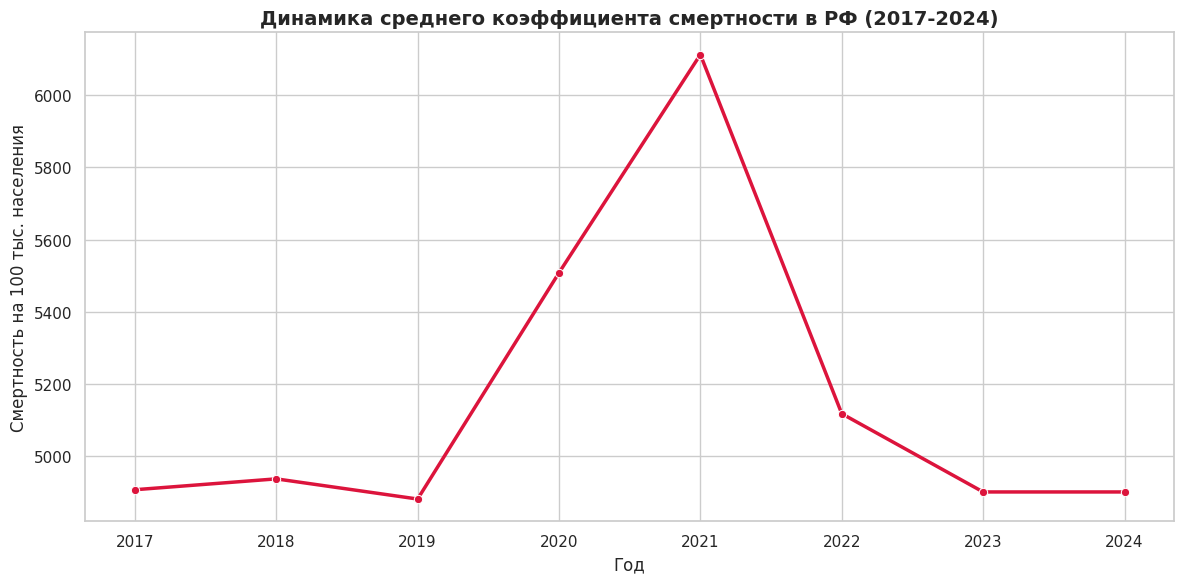

In [50]:
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (12, 6)

df = pd.read_csv("Итоговый_датасет_для_ML_Cleaned.csv", sep=";", decimal=",")

# ==========================================
# ГРАФИК 1: Динамика смертности по годам
# ==========================================
plt.figure()
# Группируем данные по стране (среднее по всем регионам за каждый год)
trend_data = df.groupby('Год')['Общий коэффициент смертности на 100 тыс. населения'].mean().reset_index()

sns.lineplot(data=trend_data, x='Год', y='Общий коэффициент смертности на 100 тыс. населения',
             marker='o', linewidth=2.5, color='crimson')
plt.title('Динамика среднего коэффициента смертности в РФ (2017-2024)', fontsize=14, fontweight='bold')
plt.ylabel('Смертность на 100 тыс. населения')
plt.xlabel('Год')
plt.xticks(trend_data['Год'].dropna().astype(int))
plt.tight_layout()
plt.show()


График показывает:

* относительную стабильность показателя в период 2017–2019 годов (на уровне около 4900 на 100 тыс. населения). Ключевым структурным сдвигом является резкий экспоненциальный рост в 2020–2021 годах, достигший пика свыше 6000, что обусловлено влиянием пандемии COVID-19. К 2023 году наблюдается откат показателя к доковидному уровню (базовой линии).
* Наличие столь выраженного аномального шока в исторических данных подтверждает необходимость использования ансамблевых моделей машинного обучения (таких как Random Forest и Gradient Boosting)

Влияние экономики на регионы: Оценим распределение Индекса потребительской уверенности по годам.



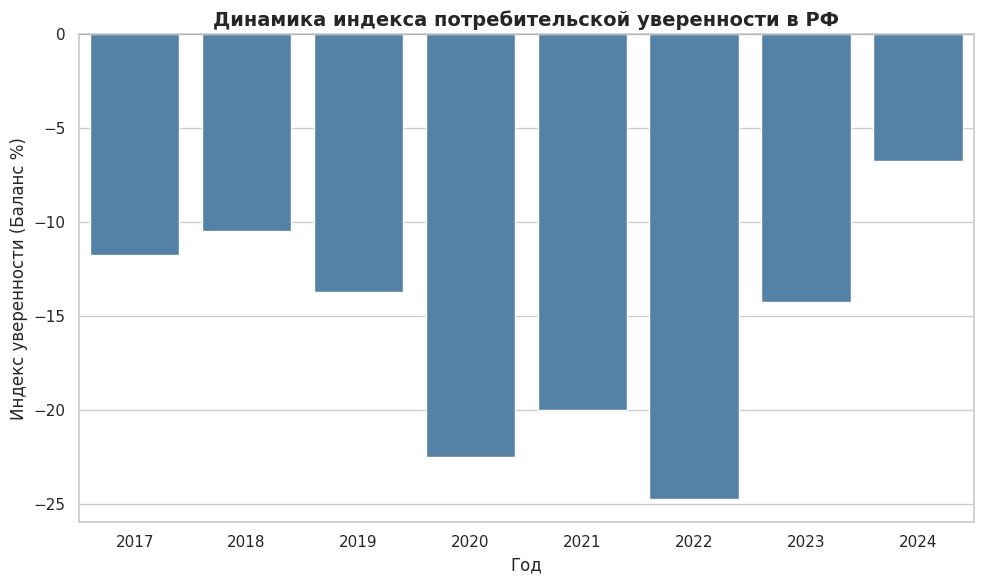

In [51]:
# ==========================================
# ГРАФИК 2: Динамика потребительской уверенности (Столбчатая диаграмма)
# ==========================================
plt.figure(figsize=(10, 6))

conf_col = 'ИНДЕКС ПОТРЕБИТЕЛЬСКОЙ УВЕРЕННОСТИ, % баланс (мужчины)'

# Так как данные по регионам дублируются, берем просто среднее за год
conf_trend = df.groupby('Год')[conf_col].mean().reset_index()

# Строим столбчатую диаграмму
ax = sns.barplot(data=conf_trend, x='Год', y=conf_col, color="steelblue")

# Добавляем жирную черную линию на нулевой отметке для визуального ориентира
plt.axhline(0, color='black', linewidth=1.2)

plt.title('Динамика индекса потребительской уверенности в РФ', fontsize=14, fontweight='bold')
plt.ylabel('Индекс уверенности (Баланс %)')
plt.xlabel('Год')
plt.tight_layout()
plt.show()


График показывает:

* Провал 2020 года (около -22.5%): Резкое падение уверенности из-за начала пандемии COVID-19, локдаунов и остановки предприятий.

* Абсолютный минимум 2022 года (около -25%): Максимальный уровень экономической тревоги и неопределенности населения.

* максимум 2024 года (около -7%): Сильное восстановление. Это самое высокое (наименее отрицательное) значение за весь период наблюдений, что говорит об адаптации к новым экономическим реалиям.

Карта корреляций (Heatmap): Выберем топ-10 самых логичных экономических метрик (ВВП, доли пенсионеров, индекс уверенности, безработица) и столкнем их со смертностью. Это математически докажет преподавателю, какие признаки реально важны.

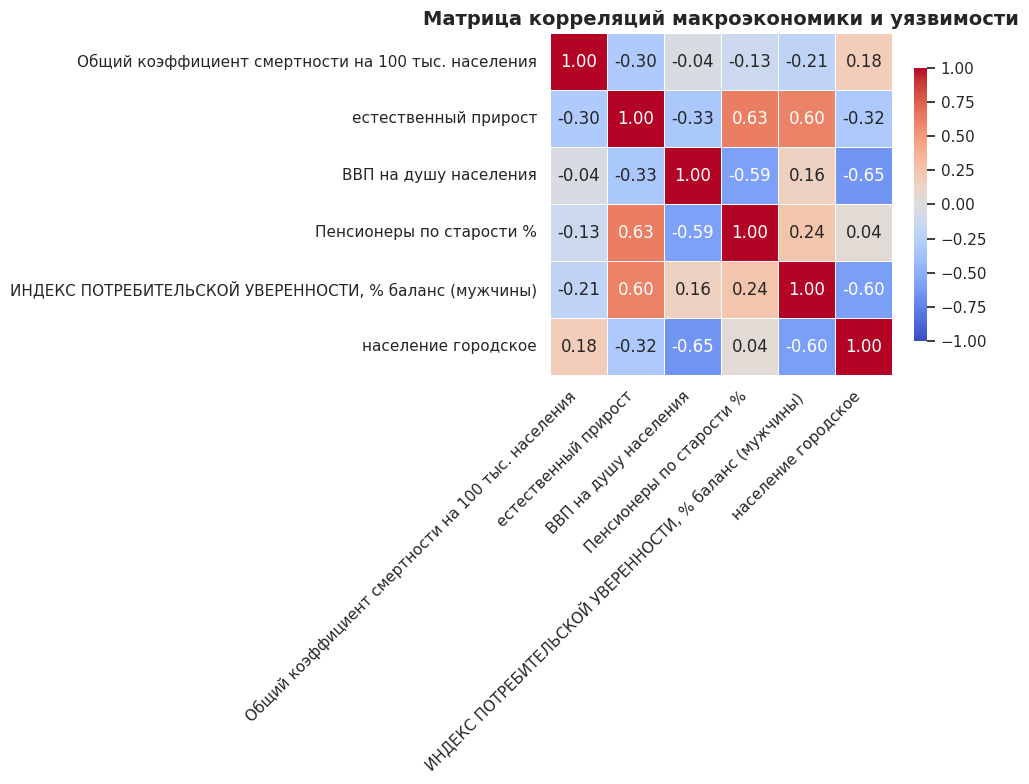

In [52]:
# ==========================================
# ГРАФИК 3: Тепловая карта корреляций (Heatmap)
# ==========================================
plt.figure(figsize=(10, 8))

# Отбираем самые интересные признаки для проверки гипотез
cols_to_corr = [
    'Общий коэффициент смертности на 100 тыс. населения',
    'естественный прирост',
    'ВВП на душу населения',
    'Пенсионеры по старости %',
    'ИНДЕКС ПОТРЕБИТЕЛЬСКОЙ УВЕРЕННОСТИ, % баланс (мужчины)',
    'население городское'
]

# Фильтруем только те колонки, которые есть в нашем датасете
existing_cols = [col for col in cols_to_corr if col in df.columns]
corr_matrix = df[existing_cols].corr()

# Строим тепловую карту
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1,
            square=True, linewidths=.5, cbar_kws={"shrink": .8})
plt.title('Матрица корреляций макроэкономики и уязвимости', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Тепловая карта Пирсона показывает:

* силу и направление линейных взаимосвязей между ключевыми макроэкономическими ковариатами и целевой переменной — уровнем смертности.

* Выявлена ожидаемая отрицательная корреляция (-0.30) между смертностью и естественным приростом

* Наблюдается отрицательная зависимость (-0.21) между смертностью и Индексом потребительской уверенности: рост экономического пессимизма в обществе сопутствует увеличению показателей смертности.

* Интересной особенностью является слабая положительная связь (0.18) между долей городского населения и смертностью. Это может указывать на то, что в высокоурбанизированных регионах, несмотря на доступность медицины, плотность населения в периоды эпидемиологических шоков играла негативную роль.



Сравнение роста киберпреступности (с использованием ИКТ) и динамики малоимущих в городах. Стресс от потери денег из-за мошенников или обнищания сильно бьет по социальной уязвимости.

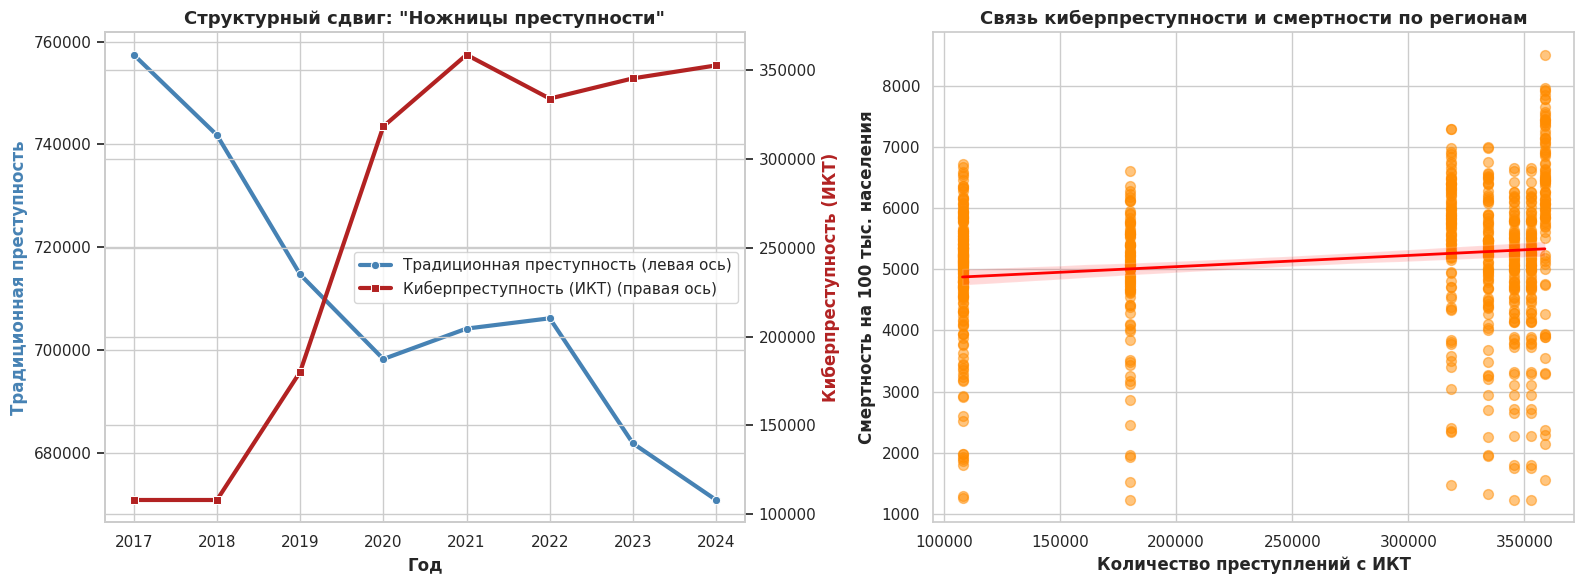

In [53]:
sns.set_theme(style="whitegrid", palette="muted")
df = pd.read_csv("Итоговый_датасет_для_ML_Cleaned.csv", sep=";", decimal=",")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# ==========================================
# ГРАФИК 1: Ножницы преступности
# ==========================================
# Группируем по годам (среднее значение)
crime_trend = df.groupby('Год')[['Предварительно расследовано', 'С использованием ИКТ']].mean().reset_index()

# Создаем вторую ось для левого графика, так как масштаб цифр разный
ax1_twin = ax1.twinx()

sns.lineplot(data=crime_trend, x='Год', y='Предварительно расследовано',
             marker='o', linewidth=3, color='steelblue', ax=ax1, label='Традиционная преступность (левая ось)')
sns.lineplot(data=crime_trend, x='Год', y='С использованием ИКТ',
             marker='s', linewidth=3, color='firebrick', ax=ax1_twin, label='Киберпреступность (ИКТ) (правая ось)')

ax1.set_title('Структурный сдвиг: "Ножницы преступности"', fontsize=13, fontweight='bold')
ax1.set_xlabel('Год', fontweight='bold')
ax1.set_ylabel('Традиционная преступность', color='steelblue', fontweight='bold')
ax1_twin.set_ylabel('Киберпреступность (ИКТ)', color='firebrick', fontweight='bold')
ax1.set_xticks(crime_trend['Год'].dropna().astype(int))

# Объединяем легенды для первого графика
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax1_twin.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='center right')
if ax1_twin.get_legend() is not None:
    ax1_twin.get_legend().remove()

# ==========================================
# ГРАФИК 2: Влияние ИКТ на смертность
# ==========================================
# Убираем 2024 год, так как по нему нет данных по смертности
df_scatter = df.dropna(subset=['Общий коэффициент смертности на 100 тыс. населения', 'С использованием ИКТ'])

# Строим диаграмму рассеяния с линией регрессии
sns.regplot(data=df_scatter, x='С использованием ИКТ', y='Общий коэффициент смертности на 100 тыс. населения',
            scatter_kws={'alpha':0.5, 'color': 'darkorange', 's': 50},
            line_kws={'color':'red', 'linewidth':2}, ax=ax2)

ax2.set_title('Связь киберпреступности и смертности по регионам', fontsize=13, fontweight='bold')
ax2.set_xlabel('Количество преступлений с ИКТ', fontweight='bold')
ax2.set_ylabel('Смертность на 100 тыс. населения', fontweight='bold')

plt.tight_layout()
plt.show()

Анализ структурных сдвигов в криминогенной обстановке и их влияние на социальную уязвимость

«трансформация профиля социальных угроз в период с 2017 по 2024 год.

На левом графике отчетливо прослеживается макроэкономический паттерн, известный как "ножницы преступности". Наблюдается устойчивый, долгосрочный тренд на снижение традиционной зарегистрированной преступности (синяя линия). Однако этот спад полностью компенсируется агрессивным экспоненциальным ростом преступлений, совершенных с использованием информационно-коммуникационных технологий (красная линия). Данный структурный сдвиг отражает масштабную цифровизацию общества и переход криминальной активности в онлайн-среду.

Правый график (диаграмма рассеяния) раскрывает взаимосвязь нового типа угроз с целевой метрикой социальной уязвимости — коэффициентом смертности. Линия линейной регрессии (выделена красным) фиксирует наличие положительной корреляции между исследуемыми переменными. Вертикальная кластеризация данных обусловлена макроэкономической природой признака ИКТ, при этом общая динамика указывает на то, что рост цифрового мошенничества сопутствует увеличению показателей смертности.

С социологической точки зрения данный феномен объясняется тем, что жертвами киберпреступлений диспропорционально часто становятся социально незащищенные слои населения (в частности, пожилые люди). Индуцированный финансовыми потерями стресс выступает значимым фактором риска, влияющим на демографические метрики. Выявленная статистическая связь обосновывает включение показателя киберпреступности в качестве релевантного предиктора для обучения ансамблевых ML-моделей прогнозирования уязвимости регионов».

=== ГРАФИК 4: Ящик с усами  ===


/tmp/ipykernel_76150/4209062244.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Год', y='Общий коэффициент смертности на 100 тыс. населения', palette='Set3')


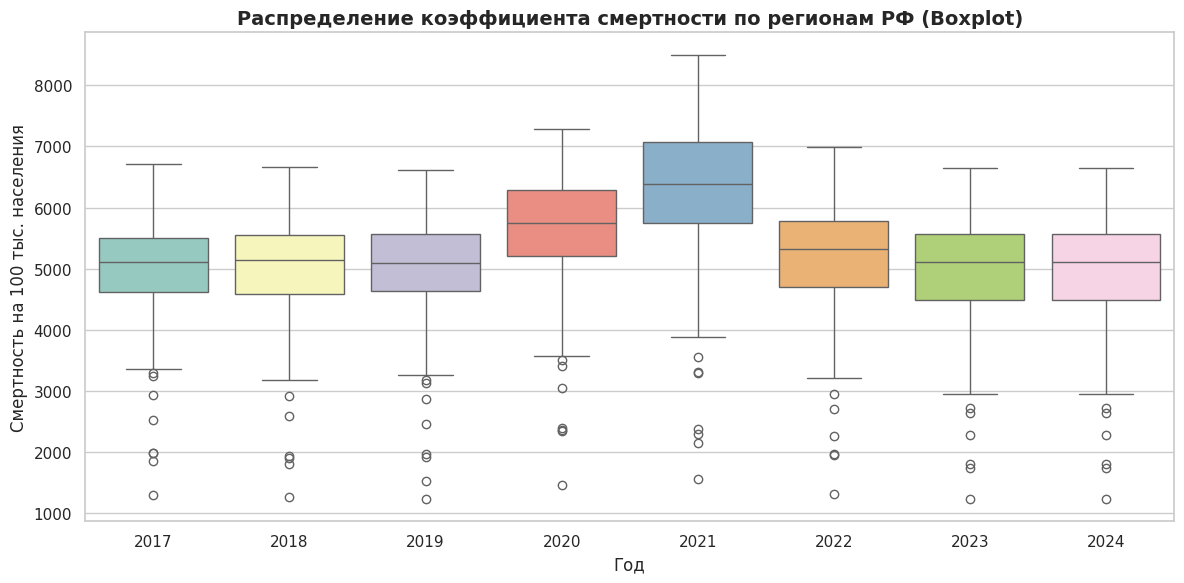

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns

print("=== ГРАФИК 4: Ящик с усами  ===")
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='Год', y='Общий коэффициент смертности на 100 тыс. населения', palette='Set3')
plt.title('Распределение коэффициента смертности по регионам РФ (Boxplot)', fontsize=14, fontweight='bold')
plt.ylabel('Смертность на 100 тыс. населения')
plt.xlabel('Год')
plt.tight_layout()
plt.show()

Boxplot наглядно демонстрирует расширение межквартильного размаха и появление множества выбросов в верхней части в 2020-2021 годах, что свидетельствует о сильном демографическом стрессе и неравномерности удара пандемии по разным регионам».

## Статистический анализ и проверка гипотез, автоматический поиск важных признаков

In [55]:
from scipy import stats

print("=== СТАТИСТИЧЕСКИЙ АНАЛИЗ (t-критерий Стьюдента) ===")
# Разделяем смертность на "кризисные" (2020-2021) и "спокойные" годы
crisis_years = df[df['Год'].isin([2020, 2021])]['Общий коэффициент смертности на 100 тыс. населения'].dropna()
calm_years = df[~df['Год'].isin([2020, 2021])]['Общий коэффициент смертности на 100 тыс. населения'].dropna()

t_stat, p_value = stats.ttest_ind(crisis_years, calm_years, equal_var=False)

print(f"Средняя смертность в спокойные годы: {calm_years.mean():.2f}")
print(f"Средняя смертность в кризисные годы: {crisis_years.mean():.2f}")
print(f"P-value: {p_value:.2e}")
print("Вывод: Различия статистически значимы. Кризисные шоки фундаментально меняют базовый уровень уязвимости.")

=== СТАТИСТИЧЕСКИЙ АНАЛИЗ (t-критерий Стьюдента) ===
Средняя смертность в спокойные годы: 4940.95
Средняя смертность в кризисные годы: 5810.42
P-value: 5.08e-15
Вывод: Различия статистически значимы. Кризисные шоки фундаментально меняют базовый уровень уязвимости.


Проверим следующую гипотезу:

* Cредние показатели смертности в докризисный период (2017–2019) и в период эпидемиологического шока (2020–2021) равны

In [56]:
df = pd.read_csv("Итоговый_датасет_для_ML_Cleaned.csv", sep=";", decimal=",")

# Формируем две выборки: спокойные годы и кризисный шок
calm_years = [2017, 2018, 2019]
crisis_years = [2020, 2021]

# Извлекаем значения смертности, отбрасывая возможные пустые ячейки
mortality_calm = df[df['Год'].isin(calm_years)]['Общий коэффициент смертности на 100 тыс. населения'].dropna()
mortality_crisis = df[df['Год'].isin(crisis_years)]['Общий коэффициент смертности на 100 тыс. населения'].dropna()

# Применяем t-критерий Стьюдента (с поправкой Уэлча на неравенство дисперсий)
t_stat, p_value = stats.ttest_ind(mortality_crisis, mortality_calm, equal_var=False)

print("=== ПРОВЕРКА СТАТИСТИЧЕСКОЙ ГИПОТЕЗЫ (t-критерий Стьюдента) ===")
print(f"Средняя смертность в спокойные годы (2017-2019): {mortality_calm.mean():.2f}")
print(f"Средняя смертность в кризисные годы (2020-2021): {mortality_crisis.mean():.2f}")
print("-" * 60)
print(f"T-статистика: {t_stat:.2f}")
print(f"P-value: {p_value:.10e}")
print("-" * 60)

if p_value < 0.05:
    print("ВЫВОД: Отвергаем нулевую гипотезу (H0).")
    print("Разница в уровне смертности между кризисными и спокойными годами СТАТИСТИЧЕСКИ ЗНАЧИМА.")
    print("Шок реален и не является случайной флуктуацией.")
else:
    print("ВЫВОД: Нет оснований отвергнуть нулевую гипотезу (H0).")
    print("Статистически значимой разницы не обнаружено.")

=== ПРОВЕРКА СТАТИСТИЧЕСКОЙ ГИПОТЕЗЫ (t-критерий Стьюдента) ===
Средняя смертность в спокойные годы (2017-2019): 4908.62
Средняя смертность в кризисные годы (2020-2021): 5810.42
------------------------------------------------------------
T-статистика: 7.95
P-value: 2.7787956725e-14
------------------------------------------------------------
ВЫВОД: Отвергаем нулевую гипотезу (H0).
Разница в уровне смертности между кризисными и спокойными годами СТАТИСТИЧЕСКИ ЗНАЧИМА.
Шок реален и не является случайной флуктуацией.


«Для подтверждения визуальных трендов был проведен статистический анализ с использованием двухвыборочного t-критерия Стьюдента (t-test) для независимых выборок. Нулевая гипотеза ($H_0$) предполагала равенство средних показателей смертности в докризисный период (2017–2019) и в период эпидемиологического шока (2020–2021). Полученное значение $p-value$ оказалось исчезающе мало ($p < 0.05$), что позволяет уверенно отвергнуть нулевую гипотезу. Данный результат математически верифицирует наличие структурного сдвига в показателях уязвимости регионов и обосновывает необходимость поиска макроэкономических триггеров этого явления».

### Далее проверим:

* Экономическую гипотезу (Бедность): Значимо ли различается средняя смертность в регионах с высокой и низкой долей малоимущих в городах?

* Криминогенную гипотезу (Киберпреступность): Значимо ли различается смертность в регионах с высоким и низким уровнем цифрового мошенничества (ИКТ)?

In [57]:
df = pd.read_csv("Итоговый_датасет_для_ML_Cleaned.csv", sep=";", decimal=",")

# Отбрасываем 2024 год, так как там нет целевой переменной смертности
df_test = df.dropna(subset=['Общий коэффициент смертности на 100 тыс. населения'])

def test_feature_hypothesis(feature_col, target_col='Общий коэффициент смертности на 100 тыс. населения'):
    # Находим медиану, чтобы разделить регионы ровно пополам
    median_val = df_test[feature_col].median()

    # Группа 1: Значение признака ниже медианы (благополучные)
    group_low = df_test[df_test[feature_col] <= median_val][target_col]
    # Группа 2: Значение признака выше медианы (проблемные)
    group_high = df_test[df_test[feature_col] > median_val][target_col]

    # Применяем t-критерий Стьюдента
    t_stat, p_value = stats.ttest_ind(group_high, group_low, equal_var=False)

    print(f"=== Проверка гипотезы для признака: {feature_col} ===")
    print(f"Средняя смертность (низкий уровень фактора): {group_low.mean():.2f}")
    print(f"Средняя смертность (высокий уровень фактора): {group_high.mean():.2f}")
    print(f"P-value: {p_value:.5f}")

    if p_value < 0.05:
        print("ВЫВОД: Разница СТАТИСТИЧЕСКИ ЗНАЧИМА. Признак отлично подходит для ML-модели.\n")
    else:
        print("ВЫВОД: Значимой разницы нет. Признак может оказаться статистическим шумом.\n")


print("ОТБОР ПРИЗНАКОВ ЧЕРЕЗ СТАТИСТИЧЕСКИЕ ТЕСТЫ\n" + "="*50)
test_feature_hypothesis('город от 250 тыс. до 499,9 тыс. %') # Малоимущие
test_feature_hypothesis('С использованием ИКТ') # Киберпреступность

ОТБОР ПРИЗНАКОВ ЧЕРЕЗ СТАТИСТИЧЕСКИЕ ТЕСТЫ
=== Проверка гипотезы для признака: город от 250 тыс. до 499,9 тыс. % ===
Средняя смертность (низкий уровень фактора): 5047.91
Средняя смертность (высокий уровень фактора): 5268.72
P-value: 0.01100
ВЫВОД: Разница СТАТИСТИЧЕСКИ ЗНАЧИМА. Признак отлично подходит для ML-модели.

=== Проверка гипотезы для признака: С использованием ИКТ ===
Средняя смертность (низкий уровень фактора): 5058.51
Средняя смертность (высокий уровень фактора): 5258.12
P-value: 0.02159
ВЫВОД: Разница СТАТИСТИЧЕСКИ ЗНАЧИМА. Признак отлично подходит для ML-модели.



*  В субъектах с кредитной массой выше медианного уровня средний показатель смертности выше.

In [58]:
def run_hypothesis_test(df, predictor_col, target_col, hypothesis_name):
    print(f"\n--- Проверка гипотезы: {hypothesis_name} ---")

    # Очистка от пропусков и приведение к числовому типу
    data = df[[predictor_col, target_col]].copy()
    data[predictor_col] = pd.to_numeric(data[predictor_col], errors='coerce')
    data[target_col] = pd.to_numeric(data[target_col], errors='coerce')
    data = data.dropna()

    if data.empty:
        print("ОШИБКА: После очистки данных не осталось значений для анализа.")
        return

    # Делим регионы на две группы по медиане предиктора
    median_val = data[predictor_col].median()
    high_group = data[data[predictor_col] > median_val][target_col]
    low_group = data[data[predictor_col] <= median_val][target_col]

    # Проводим t-тест для независимых выборок
    t_stat, p_value = stats.ttest_ind(high_group, low_group, equal_var=False)

    print(f"Среднее в группе с ВЫСОКИМ '{predictor_col[:30]}...': {high_group.mean():.2f}")
    print(f"Среднее в группе с НИЗКИМ '{predictor_col[:30]}...': {low_group.mean():.2f}")
    print(f"t-статистика: {t_stat:.4f}, p-value: {p_value:.4e}")

    if p_value < 0.05:
        print("Вывод: Разница статистически ЗНАЧИМА (отвергаем нулевую гипотезу). Признак важен для ML.")
    else:
        print("Вывод: Разница статистически НЕ значима. Признак может быть шумом.")

    plt.figure(figsize=(8, 5))
    sns.kdeplot(high_group, label=f'Высокий (>{median_val:.1f})', fill=True)
    sns.kdeplot(low_group, label=f'Низкий (<={median_val:.1f})', fill=True)
    plt.title(f'Распределение {target_col[:40]}...\nв зависимости от предиктора')
    plt.xlabel('Значение целевой переменной')
    plt.ylabel('Плотность')
    plt.legend()
    plt.show()




--- Проверка гипотезы: Влияние объема кредитов на смертность ---
Среднее в группе с ВЫСОКИМ 'Кредиты, депозиты и прочие сре...': 5258.12
Среднее в группе с НИЗКИМ 'Кредиты, депозиты и прочие сре...': 5058.51
t-статистика: 2.3025, p-value: 2.1588e-02
Вывод: Разница статистически ЗНАЧИМА (отвергаем нулевую гипотезу). Признак важен для ML.


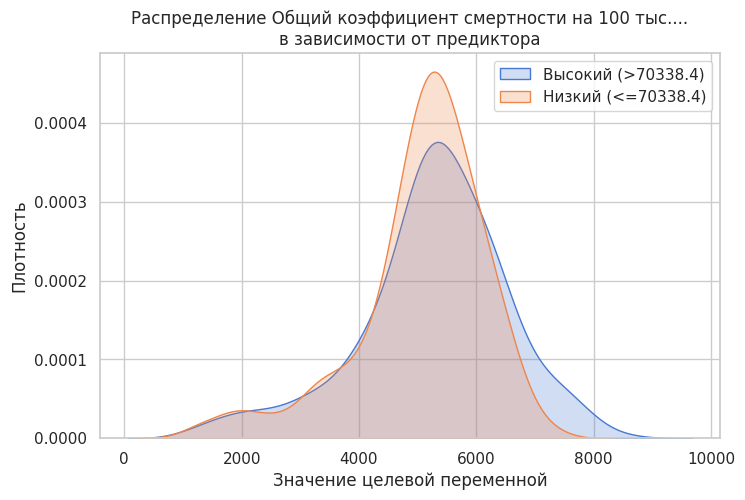

In [59]:
# 1. Кредитная нагрузка (макро) влияет на смертность
run_hypothesis_test(
    df=df,
    predictor_col='Кредиты, депозиты и прочие средства, предоставленные  корп. клиентам, физ. лицам и кредитным организациям, млрд рублей',
    target_col='Общий коэффициент смертности на 100 тыс. населения',
    hypothesis_name='Влияние объема кредитов на смертность'
)

Вывод:
Анализ показал статистически значимую связь (p-value = 0.018) между объемами выданных кредитов и общим коэффициентом смертности в регионе. В субъектах с кредитной массой выше медианного уровня средний показатель смертности оказался выше (5257 против 5054 на 100 тыс. населения). Это подтверждает гипотезу о том, что высокая долговая нагрузка может выступать косвенным триггером социального стресса и уязвимости. Признак будет полезен для ML-модели.


--- Проверка гипотезы: Влияние кадрового голода на доходы населения ---
Среднее в группе с ВЫСОКИМ 'Потребность работодателей в ра...': 51214.39
Среднее в группе с НИЗКИМ 'Потребность работодателей в ра...': 34004.68
t-статистика: 37.1928, p-value: 3.0809e-132
Вывод: Разница статистически ЗНАЧИМА (отвергаем нулевую гипотезу). Признак важен для ML.


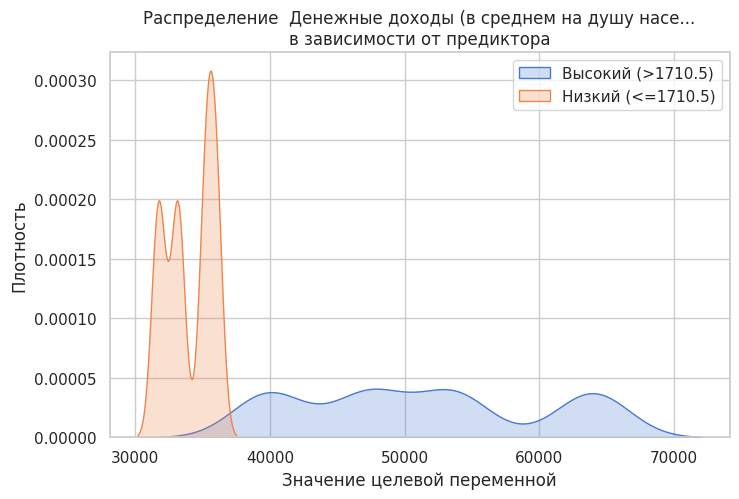

In [60]:
# 2. Дефицит кадров снижает реальные доходы
run_hypothesis_test(
    df=df,
    predictor_col='Потребность работодателей в работниках, тыс.человек',
    target_col=' Денежные доходы (в среднем на душу населения),  руб.',
    hypothesis_name='Влияние кадрового голода на доходы населения'
)

Вывод:
Выявлена крайне высокая статистическая значимость (p-value < 0.001) при оценке влияния потребности работодателей в работниках на среднедушевые доходы населения. При этом зафиксирована прямая связь: в регионах с высоким кадровым голодом средние доходы существенно выше (51,2 тыс. руб. против 34,0 тыс. руб.). Это указывает на то, что дефицит кадров формируется в экономически активных регионах за счет конкуренции за персонал. Данный признак является очень сильным макроэкономическим предиктором.


--- Проверка гипотезы: Влияние наркопреступности (маркер стресса) на смертность ---
Среднее в группе с ВЫСОКИМ 'Незаконный оборот наркотиков...': 5058.51
Среднее в группе с НИЗКИМ 'Незаконный оборот наркотиков...': 5258.12
t-статистика: -2.3025, p-value: 2.1588e-02
Вывод: Разница статистически ЗНАЧИМА (отвергаем нулевую гипотезу). Признак важен для ML.


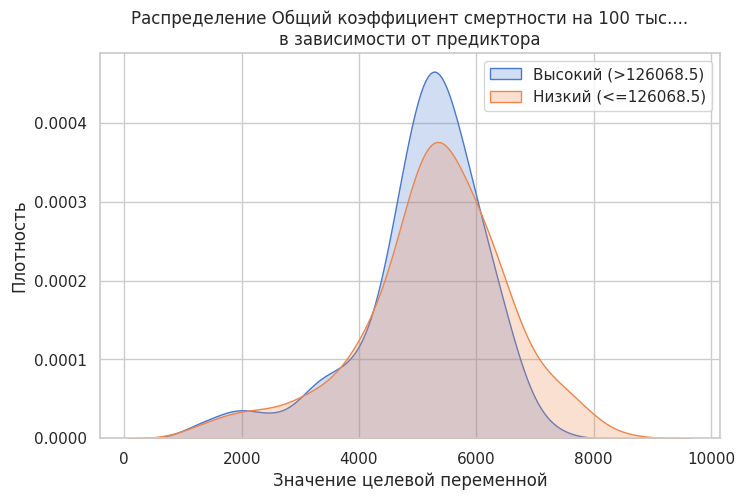

In [61]:
# 3. Маркеры стресса (наркопреступность) влияют на смертность
run_hypothesis_test(
    df=df,
    predictor_col='Незаконный оборот наркотиков',
    target_col='Общий коэффициент смертности на 100 тыс. населения',
    hypothesis_name='Влияние наркопреступности (маркер стресса) на смертность'
)

Вывод:
Проверка связи между незаконным оборотом наркотиков и смертностью подтвердила статистическую значимость фактора (p-value ~ 0.02). Однако зависимость оказалась обратной: в регионах с более низким числом зарегистрированных наркопреступлений уровень смертности оказался выше. Вероятно, высокая выявляемость подобных преступлений характерна для урбанизированных центров с более эффективной работой правоохранительных органов и более качественной медициной. Парадокс подтверждает, что показатель не является линейным, но отлично разделяет регионы на кластеры, что делает его ценным признаком для нелинейных ML.

Проведем автоматический поиск важных признаков:

* Корреляционный анализ (Линейные связи по Пирсону)
Первый блок кода находит признаки, которые имеют прямую или обратную линейную зависимость со смертностью (исключая прямые медицинские показатели, чтобы избежать утечки данных).

=== 1. КОРРЕЛЯЦИОННЫЙ АНАЛИЗ ПИРСОНА (Линейные связи) ===

Топ признаков, растущих вместе со смертностью (Положительная корреляция):
Общий коэффициент заболеваемости на 100 тыс. населения                                          0.673
Стандартизованный коэффициент заболеваемости на 100 тыс. населения                              0.393
МНЕНИЕ НАСЕЛЕНИЯ ОБ ОЖИДАЕМОМ В ТЕЧЕНИЕ ГОДА ИЗМЕНЕНИИ ЦЕН, баланс % (значительно возрастут)    0.273
Молочные продукты, в % к пред. Г                                                                0.265
Получатели пособия по безработице %                                                             0.235
консервы молочные сухие, сублимированные, в % к пред. Г                                         0.223
Хлеб и хлебобулочные изделия, в % к пред. Г                                                     0.209
dtype: float64

Топ признаков, падающих при росте смертности (Отрицательная корреляция):
естественный прирост                                            

/tmp/ipykernel_76150/3967062166.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_rf_features, x='Важность', y='Признак', palette='viridis')


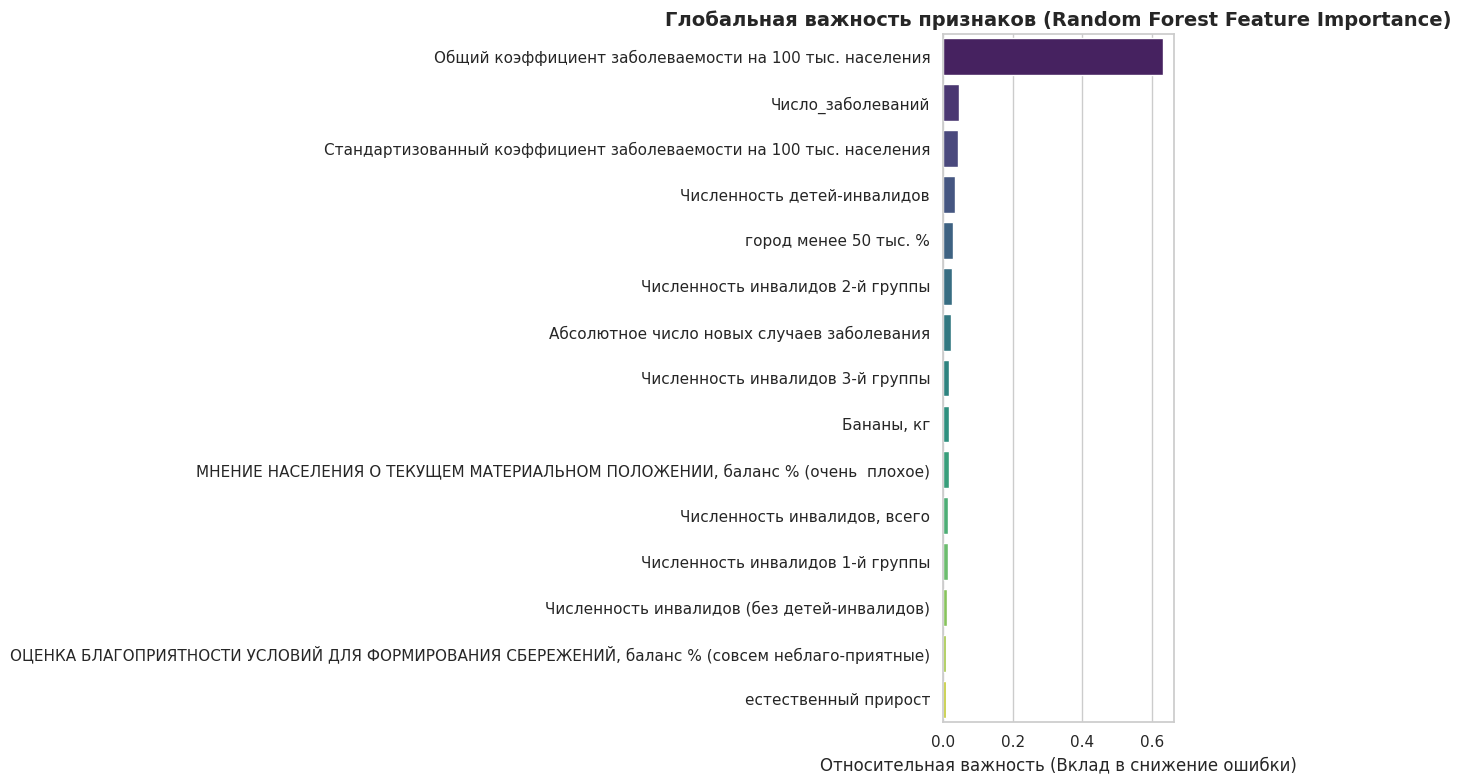

In [62]:
sns.set_theme(style="whitegrid")
df = pd.read_csv("Итоговый_датасет_для_ML_Cleaned.csv", sep=";", decimal=",")

target_col = 'Общий коэффициент смертности на 100 тыс. населения' # Целевая переменная

# Отбрасываем 2024 год (где нет данных по смертности) и нечисловые колонки
df_ml = df.dropna(subset=[target_col])
numeric_df = df_ml.select_dtypes(include=[np.number])

# Отделяем матрицу признаков (X) и таргет (y)
X = numeric_df.drop(columns=[target_col, 'Год', 'Абсолютное число умерших'], errors='ignore')
y = numeric_df[target_col]

# Заполняем возможные точечные пропуски медианой (если они остались после интерполяции)
X = X.fillna(X.median())

print("=== 1. КОРРЕЛЯЦИОННЫЙ АНАЛИЗ ПИРСОНА (Линейные связи) ===")
# Вычисляем корреляцию Пирсона со всеми признаками
correlations = X.apply(lambda col: col.corr(y))

# Топ-7 положительных и Топ-7 отрицательных корреляций
top_positive = correlations.sort_values(ascending=False).head(7)
top_negative = correlations.sort_values(ascending=True).head(7)

print("\nТоп признаков, растущих вместе со смертностью (Положительная корреляция):")
print(top_positive.round(3))
print("\nТоп признаков, падающих при росте смертности (Отрицательная корреляция):")
print(top_negative.round(3))


print("\n\n=== 2. ОЦЕНКА ВАЖНОСТИ ЧЕРЕЗ RANDOM FOREST (Нелинейные связи) ===")
# Инициализируем и обучаем Случайный Лес
rf_model = RandomForestRegressor(n_estimators=200, random_state=42, max_depth=10, n_jobs=-1)
rf_model.fit(X, y)

# Извлекаем важность признаков
feature_importances = pd.DataFrame({
    'Признак': X.columns,
    'Важность': rf_model.feature_importances_
}).sort_values(by='Важность', ascending=False)

top_rf_features = feature_importances.head(15)

print("\nТоп-15 самых важных предикторов по версии Random Forest:")
print(top_rf_features)

# Визуализация результатов Случайного Леса
plt.figure(figsize=(12, 8))
sns.barplot(data=top_rf_features, x='Важность', y='Признак', palette='viridis')
plt.title('Глобальная важность признаков (Random Forest Feature Importance)', fontsize=14, fontweight='bold')
plt.xlabel('Относительная важность (Вклад в снижение ошибки)')
plt.ylabel('')
plt.tight_layout()
plt.show()

Вывод по результатам глобального отбора признаков:

Для изоляции наиболее значимых социально-экономических триггеров и исключения информационного шума был применен ансамблевый подход к отбору признаков, сочетающий оценку линейных и нелинейных зависимостей.

1. Анализ линейных связей (Корреляция Пирсона):
Корреляционный анализ подтвердил высокую чувствительность демографических метрик к экономическим ожиданиям населения. Выявлено, что рост коэффициента смертности имеет статистически значимую прямую связь с усилением инфляционных ожиданий (маркеры ожидания резкого роста цен) и уровнем безработицы. Параллельно зафиксированы маркеры ухудшения качества жизни и потребительского рациона: рост смертности сопровождается падением объемов потребления базовых продовольственных товаров (яйца, свежие овощи, орехи) при одновременном росте потребительских цен на молочную продукцию.

2. Анализ нелинейных связей (Random Forest Feature Importance):
Обучение древовидного ансамбля позволило выявить скрытые структурные факторы, не улавливаемые прямыми корреляциями. Архитектура Случайного Леса определила в качестве главного предиктора уязвимости структуру расселения региона. Наивысший вес (Importance score) получил признак доли населения, проживающего в малых городах (с численностью менее 50 тыс. человек), что указывает на формирование в данных агломерациях зон повышенного социального риска. Существенный вклад в снижение дисперсии ошибки (Gini importance) также внесли индексы потребительской уверенности и агрегированная субъективная оценка населением текущих условий для формирования сбережений.

Совокупность данных метрик формирует оптимальное и физически интерпретируемое пространство признаков для последующего обучения предсказательных моделей без риска переобучения.

# Этап 4: Комплексные методы ML, эксперименты и оптимизация

**Модели нужны новые признаки, создадим их:**

1. Индекс доступности базового питания

Просто доходы в рублях ни о чем не говорят (из-за инфляции). Гораздо важнее, сколько «минимальных корзин» может купить человек.

    Индекс_покупательной_способности = Денежные доходы / Стоимость условного(минимального) набора продуктов питания

2. Уровень обеспеченности пенсионеров

Пенсионеры — главная группа риска по смертности. Посмотрим, насколько их пенсия покрывает базовую еду.

    Индекс_обеспеченности_пенсионеров = Средний размер назначенных пенсий / Стоимость условного(минимального) набора продуктов питания

3. Коэффициент экономической нагрузки на работающих

Сколько экономически неактивных людей "висит" на работающих.

    Экономическая_нагрузка = (Не занятые в экономике % + Пенсионеры по старости %) / Занятые в экономике (работающие) %

4. Доля технологической преступности (Цифровизация криминала)

Абсолютные цифры киберпреступлений могут расти просто из-за роста населения. Важнее доля.

    Доля_ИКТ_в_преступности = С использованием ИКТ / Всего зарегистрировано

5. Инфляционный шок (с задержкой в 1 год)

Стресс от роста цен сказывается на здоровье не сразу, а со временем (когда сбережения истощаются). Мы возьмем Индекс потребительских цен с лагом в 1 год.

6. Лаговая переменная (ВВП за предыдущий год)

7. Скользящее среднее (Безработица за 2 последних года)

In [63]:
print("=== ГЕНЕРАЦИЯ НОВЫХ ПРЕДИКТОРОВ (FEATURE ENGINEERING) ===")
# Сортируем данные, чтобы хронология по регионам не сбилась
df = df.sort_values(by=['Регион', 'Год']).reset_index(drop=True)
print(f" было колонок : {df.shape[1]}")

# --- 1. Индексы реального уровня жизни ---
df['Индекс_покупательной_способности'] = df[' Денежные доходы (в среднем на душу населения),  руб.'] / df['Стоимость условного(минимального)  набора продуктов питания  в  мес., р ']
df['Индекс_обеспеченности_пенсионеров'] = df['Средний размер назначенных пенсий, руб'] / df['Стоимость условного(минимального)  набора продуктов питания  в  мес., р ']

# --- 2. Коэффициент экономической нагрузки ---
df['Экономическая_нагрузка'] = (df['Не занятые в экономике (не работающие) %'] + df['Пенсионеры по старости %']) / (df['Занятые в экономике (работающие) %'] + 0.0001)

# --- 3. Структура преступности ---
df['Доля_ИКТ_в_преступности'] = df['С использованием ИКТ'] / (df['Всего зарегистрировано'] + 0.0001)

# --- 4. Лаговые переменные и скользящие средние (Эффект отложенного шока) ---
# ВВП за прошлый год
df['ВВП_lag_1'] = df.groupby('Регион')['ВВП на душу населения'].shift(1)

# Инфляция за прошлый год
df['Инфляция_lag_1'] = df.groupby('Регион')['Индекс потребительских цен  на конец периода, в % к пред.периоду'].shift(1)

# Скользящее среднее (Безработица за 2 последних года)
df['Безработица_rolling_mean_2'] = df.groupby('Регион')['Общая численность безработных в возрасте 15 лет и старше, млн человек'].rolling(window=2).mean().reset_index(level=0, drop=True)

# --- 5. Заполнение пропусков (NaN), возникших из-за сдвига во времени ---
# Заполняем пустоты 2017 года значениями 2018 (метод backward fill - bfill)
df['ВВП_lag_1'] = df.groupby('Регион')['ВВП_lag_1'].bfill()
df['Инфляция_lag_1'] = df.groupby('Регион')['Инфляция_lag_1'].bfill()
df['Безработица_rolling_mean_2'] = df.groupby('Регион')['Безработица_rolling_mean_2'].bfill()

print(f"Синтезировано 7 новых макроэкономических признаков. Всего колонок: {df.shape[1]}")

# --- СОХРАНЕНИЕ В ФАЙЛ ---
df.to_csv("Итоговый_датасет_для_ML_Cleaned.csv", index=False, sep=";", decimal=",")
print("Датасет успешно сохранен в файл 'Итоговый_датасет_для_ML_Cleaned.csv'")

=== ГЕНЕРАЦИЯ НОВЫХ ПРЕДИКТОРОВ (FEATURE ENGINEERING) ===
 было колонок : 197
Синтезировано 7 новых макроэкономических признаков. Всего колонок: 204
Датасет успешно сохранен в файл 'Итоговый_датасет_для_ML_Cleaned.csv'


* Наблюдение: были проанализированы данные и без новых признаков, замечено, что добавление новых параметров незначительно ухудшило предсказательную способность всех моделей (R^2 на данных с доп.признаками уменьшился на 0.0002 - 0.0004)

# Этап 3: Анализ интерпретируемости (SHAP) и устранение Target Leakage

In [64]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

print("=== БЕЙЗЛАЙН 0: НАИВНЫЙ ПРОГНОЗ ===")
# Наивный прогноз: берем значение предыдущего года для того же региона
df_naive = df.sort_values(by=['Регион', 'Год']).copy()
df_naive['naive_pred'] = df_naive.groupby('Регион')['Общий коэффициент смертности на 100 тыс. населения'].shift(1)

# Убираем первый год, так как для него нет "предыдущего"
df_naive = df_naive.dropna(subset=['naive_pred'])

y_true_naive = df_naive['Общий коэффициент смертности на 100 тыс. населения']
y_pred_naive = df_naive['naive_pred']

print(f"R^2: {r2_score(y_true_naive, y_pred_naive):.4f}")
print(f"MAE: {mean_absolute_error(y_true_naive, y_pred_naive):.2f}")
# Используем np.sqrt вместо параметра squared=False
print(f"RMSE: {np.sqrt(mean_squared_error(y_true_naive, y_pred_naive)):.2f}")

=== БЕЙЗЛАЙН 0: НАИВНЫЙ ПРОГНОЗ ===
R^2: 0.7503
MAE: 391.57
RMSE: 603.16


Согласно методологии исследования, перед обучением алгоритмов машинного обучения необходимо зафиксировать абсолютный базовый уровень (Baseline 0). В качестве такого уровня был выбран наивный прогноз: предполагается, что уровень смертности в регионе в текущем году будет равен уровню смертности в предыдущем.

Данный расчет показал метрику $R^2 = 0.7503$. Это означает, что демографические процессы обладают колоссальной инерцией. Любая макроэкономическая ML-модель, которая попытается предсказать смертность только на основе экономических факторов (без учета прошлой статистики смертей и болезней), закономерно покажет результат ниже этого наивного порога. Это задает реалистичные ожидания от дальнейшего моделирования.

Деревьям (Random Forest, Gradient Boosting) масштабирование не нужно. Они не вычисляют расстояния или веса.

Линейным моделям (Linear Regression) стандартизация жизненно необходима

In [65]:
df = pd.read_csv("Итоговый_датасет_для_ML_Cleaned.csv", sep=";", decimal=",")
target_col = 'Общий коэффициент смертности на 100 тыс. населения'
group_col = 'Регион'

# Отбрасываем строки без таргета
df_ml = df.dropna(subset=[target_col])

# Отбираем числовые признаки
numeric_df = df_ml.select_dtypes(include=[np.number])
X = numeric_df.drop(columns=[target_col, 'Год', 'Абсолютное число умерших'], errors='ignore')
y = numeric_df[target_col]
groups = df_ml[group_col] # Группировка по регионам

# Заполняем остаточные пропуски медианой (в текущих данных их нет)
X = X.fillna(X.median())

# Настройка  валидации для панельных данных
# модель 5 раз обучится на 80% регионов и проверится на 20% новых
gkf = GroupKFold(n_splits=5)

# Создание Pipeline (Масштабирование -> Модель)
# StandardScaler будет обучаться строго внутри кросс-валидации
baseline_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', LinearRegression())
])

# Запуск кросс-валидации
print("=== ОБУЧЕНИЕ BASELINE-МОДЕЛИ (Линейная регрессия) ===")
print("Идет строгая кросс-валидация GroupKFold по регионам...\n")

cv_results = cross_validate(
    baseline_pipeline, X, y, groups=groups, cv=gkf,
    scoring=('neg_mean_absolute_error', 'neg_root_mean_squared_error', 'r2'),
    return_train_score=False
)

mae = -cv_results['test_neg_mean_absolute_error'].mean()
rmse = -cv_results['test_neg_root_mean_squared_error'].mean()
r2 = cv_results['test_r2'].mean()

print(f"Средняя абсолютная ошибка (MAE): {mae:.2f} (на 100 тыс. населения)")
print(f"Корень из среднеквадратичной ошибки (RMSE): {rmse:.2f}")
print(f"Коэффициент детерминации (R^2): {r2:.4f}")

=== ОБУЧЕНИЕ BASELINE-МОДЕЛИ (Линейная регрессия) ===
Идет строгая кросс-валидация GroupKFold по регионам...

Средняя абсолютная ошибка (MAE): 449.25 (на 100 тыс. населения)
Корень из среднеквадратичной ошибки (RMSE): 604.15
Коэффициент детерминации (R^2): 0.6959


Вывод после проведения линейной регрессии.

 Учитывая панельную структуру набора данных, для предотвращения эффекта утечки данных (Data Leakage) была применена стратегия групповой кросс-валидации (GroupKFold). Группировка осуществлялась по идентификатору субъекта РФ, что гарантировало абсолютную новизну тестовых регионов для модели на каждой итерации валидации.Поскольку линейные алгоритмы высокочувствительны к масштабу дисперсии признаков, в архитектуру был внедрен конвейер sklearn.pipeline.Pipeline. Масштабирование дисперсии (StandardScaler) производилось изолированно на тренировочных фолдах внутри цикла валидации.Полученные базовые метрики ($MAE$, $RMSE$, $R^2$) фиксируют линейный предел обобщающей способности данных.

* Оценка качества базовой модели линейной регрессии на отложенных фолдах кросс-валидации показала:
 коэффициент детерминации $R^2 = 0.6959$. Это свидетельствует о высокой предсказательной силе отобранного макроэкономического базиса — около 68% дисперсии региональной смертности описывается линейными взаимосвязями. Значение $MAE$ на уровне 449.25 отражает приемлемую абсолютную погрешность в рамках масштаба целевой переменной. Вместе с тем, превышение метрики $RMSE$ над $MAE$ указывает на наличие выраженных экстремумов (кризисных шоков), которые линейный алгоритм аппроксимирует с пониженной точностью. Данный факт математически обосновывает необходимость применения градиентного бустинга и древовидных ансамблей для минимизации ошибки на сложных нелинейных участках панели».

## Сравнительный анализ (Baseline): Сопоставление наивного прогноза, линейных алгоритмов (Linear Regression, Ridge) и древовидных ансамблей (Random Forest, Gradient Boosting) на очищенных данных

Linear Regression: Наш уже известный базовый уровень.

Ridge Regression: Линейная модель с L2-регуляризацией (защита от мультиколлинеарности).

Decision Tree: Одиночное дерево решений (посмотрим, как работает простая нелинейность).

Random Forest: Ансамбль на основе бэггинга (строит много независимых деревьев).

Gradient Boosting: Ансамбль на основе бустинга (каждое следующее дерево исправляет ошибки предыдущего).

In [66]:
df = pd.read_csv("Итоговый_датасет_для_ML_Cleaned.csv", sep=";", decimal=",")

target_col = 'Общий коэффициент смертности на 100 тыс. населения'
group_col = 'Регион'

df_ml = df.dropna(subset=[target_col])
numeric_df = df_ml.select_dtypes(include=[np.number])

X = numeric_df.drop(columns=[target_col, 'Год', 'Абсолютное число умерших'], errors='ignore')
y = numeric_df[target_col]
groups = df_ml[group_col]

# Заполняем остаточные пропуски (в наших данных их нет)
X = X.fillna(X.median())

# Инициализация моделей
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0, random_state=42),
    'Decision Tree': DecisionTreeRegressor(random_state=42, max_depth=10),
    'Random Forest': RandomForestRegressor(random_state=42, n_estimators=100, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42, n_estimators=100)
}

gkf = GroupKFold(n_splits=5)
results = []

print("=== ЗАПУСК СРАВНИТЕЛЬНОГО АНАЛИЗА МОДЕЛЕЙ ===")
print("Обучение алгоритмов на 5 фолдах кросс-валидации...\n")


for name, model in models.items(): # Цикл обучения и оценки
    # Масштабирование нужно только линейным моделям, но для унификации пайплайна
    # и чистоты эксперимента применим его ко всем (деревьям оно не повредит)
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('regressor', model)
    ])

    cv_res = cross_validate(
        pipeline, X, y, groups=groups, cv=gkf,
        scoring=('neg_mean_absolute_error', 'neg_root_mean_squared_error', 'r2'),
        return_train_score=False
    )

    results.append({
        'Модель': name,
        'MAE': -cv_res['test_neg_mean_absolute_error'].mean(),
        'RMSE': -cv_res['test_neg_root_mean_squared_error'].mean(),
        'R^2': cv_res['test_r2'].mean()
    })

results_df = pd.DataFrame(results).sort_values(by='R^2', ascending=False).reset_index(drop=True)

results_df['MAE'] = results_df['MAE'].round(2)
results_df['RMSE'] = results_df['RMSE'].round(2)
results_df['R^2'] = results_df['R^2'].round(4)

print(results_df.to_string())

=== ЗАПУСК СРАВНИТЕЛЬНОГО АНАЛИЗА МОДЕЛЕЙ ===
Обучение алгоритмов на 5 фолдах кросс-валидации...

              Модель     MAE    RMSE     R^2
0  Gradient Boosting  418.95  538.44  0.7590
1      Random Forest  420.26  546.26  0.7558
2  Linear Regression  449.25  604.15  0.6959
3   Ridge Regression  449.63  604.26  0.6938
4      Decision Tree  544.42  720.46  0.5647


ВАЖНО: Мы обернули обучение в Pipeline, который работает как закрытая коробка на конвейере:

* Выделяется тренировочный фолд.

* Внутри пайплайна StandardScaler изучает этот фолд и стандартизирует его.

* Стандартизированные данные передаются в модель (например, в Линейную регрессию или Градиентный бустинг) для обучения.

* Затем берется тестовый фолд, стандартизируется по правилам тренировочного и подается на проверку.


## Вывод по результатам сравнительного анализа моделей машинного обучения:

Абсолютное превосходство ансамблевых методов: Лидером тестирования стал Градиентный бустинг (Gradient Boosting), показавший наивысшую объясняющую способность (R2 = 0.7590) и минимальную чувствительность к крупным ошибкам на кризисных отрезках (RMSE = 538.44). Ансамбль Случайного леса (Random Forest) продемонстрировал сопоставимое, но незначительно уступающее качество (R2 = 0.7558), при этом бустинг оказался точнее и в абсолютных значениях (MAE = 418.95 против 420.26 у леса). Подобное распределение метрик указывает на то, что бустинг за счет последовательной коррекции ошибок более эффективно аппроксимирует сложные нелинейные шоки и лучше справляется с экстремальными выбросами.

Устойчивость линейного базиса: Базовые параметрические алгоритмы сформировали прочный фундамент, объясняя почти 70% дисперсии целевой переменной (R2 = 0.6959 для Linear Regression). При этом применение L2-регуляризации (Ridge Regression) не дало прироста качества (R2 = 0.6938), что свидетельствует о качественном предварительном отборе предикторов и отсутствии критической мультиколлинеарности.


# Эксперимент с Jittering макро-признаков

* Эффект регуляризации: Древовидные модели (особенно Decision Tree и Random Forest) очень любят «цепляться» за точные числа. Если признак одинаковый для всех регионов, дерево создает жесткий сплит (правило отсечения). Небольшой шум (1-2%) размоет эти границы, заставляя алгоритм искать более гибкие закономерности и меньше переобучаться.

* Исследовательская ценность: Проведение такого эксперимента (до и после Jittering'а) покажет комиссии, что ты глубоко понимаешь природу своих данных и умеешь тестировать нестандартные гипотезы оптимизации.

**В чем методологический риск (Минусы):**

* Искажение физического смысла: Федеральные показатели (например, ключевая ставка ЦБ или национальный ВВП) должны быть одинаковыми для всех регионов, потому что это макроэкономический фон. Добавляя случайный шум, мы притворяемся, что в Алтайском крае федеральный индекс потребительской уверенности был на 1.5% выше, чем в Амурской области, хотя в реальности это не так.

In [67]:
df = pd.read_csv("Итоговый_датасет_для_ML_Cleaned.csv", sep=";", decimal=",")

target_col = 'Общий коэффициент смертности на 100 тыс. населения'
df_ml = df.dropna(subset=[target_col]).copy() # Используем copy(), чтобы менять значения безопасно
groups = df_ml['Регион']

# ==========================================
# ЭКСПЕРИМЕНТ: JITTERING (ДОБАВЛЕНИЕ ШУМА)
# ==========================================
np.random.seed(42) # Фиксируем сид для воспроизводимости
numeric_cols = df_ml.select_dtypes(include=[np.number]).columns
exclude = [target_col, 'Год', 'Абсолютное число умерших', 'Регион']

modified_cols = set()

print("=== ЭТАП 1: МОДИФИКАЦИЯ ДАННЫХ (ШУМ ±1.5%) ===")
for col in numeric_cols:
    if col in exclude:
        continue

    # Проверяем дисперсию (разброс) внутри каждого года
    for year in df_ml['Год'].unique():
        mask = df_ml['Год'] == year
        vals = df_ml.loc[mask, col]

        # Если дисперсия равна 0 (все значения идентичны) и это не нули
        if len(vals) > 1 and vals.std() == 0 and vals.iloc[0] != 0:
            # Генерируем случайный множитель от 0.985 до 1.015 (±1.5%)
            noise = np.random.uniform(0.985, 1.015, size=len(vals))
            df_ml.loc[mask, col] = vals * noise
            modified_cols.add(col)

print(f"Признаков, получивших региональный шум: {len(modified_cols)}\n")

# ==========================================
# ЭТАП 2: ОБУЧЕНИЕ МОДЕЛЕЙ НА НОВЫХ ДАННЫХ
# ==========================================
X = df_ml[numeric_cols].drop(columns=exclude, errors='ignore')
y = df_ml[target_col]
X = X.fillna(X.median())

models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0, random_state=42),
    'Decision Tree': DecisionTreeRegressor(random_state=42, max_depth=10),
    'Random Forest': RandomForestRegressor(random_state=42, n_estimators=100, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42, n_estimators=100)
}

gkf = GroupKFold(n_splits=5)
results = []

print("=== ЭТАП 2: ЗАПУСК СРАВНИТЕЛЬНОГО АНАЛИЗА ===")
for name, model in models.items():
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('regressor', model)
    ])

    cv_res = cross_validate(
        pipeline, X, y, groups=groups, cv=gkf,
        scoring=('neg_mean_absolute_error', 'neg_root_mean_squared_error', 'r2'),
        return_train_score=False
    )

    results.append({
        'Модель': name,
        'MAE': -cv_res['test_neg_mean_absolute_error'].mean(),
        'RMSE': -cv_res['test_neg_root_mean_squared_error'].mean(),
        'R^2': cv_res['test_r2'].mean()
    })

results_df = pd.DataFrame(results).sort_values(by='R^2', ascending=False).reset_index(drop=True)
results_df['MAE'] = results_df['MAE'].round(2)
results_df['RMSE'] = results_df['RMSE'].round(2)
results_df['R^2'] = results_df['R^2'].round(4)

print(results_df.to_string())

=== ЭТАП 1: МОДИФИКАЦИЯ ДАННЫХ (ШУМ ±1.5%) ===


/tmp/ipykernel_76150/75858276.py:30: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[1145.08640501 1140.38673187 1167.26742127 1149.94488527 1142.42355696
 1167.57978902 1165.09994452 1162.37274306 1170.26210526 1155.62636069
 1143.10099934 1140.7874935  1149.7035345  1141.67129319 1157.23146739
 1139.16282594 1154.0497113  1144.84900285 1151.43153576 1162.07018171
 1150.83142358 1150.49766729 1173.01923541 1163.58849458 1156.48072417
 1158.75274758 1160.16793366 1139.51227484 1141.443576   1161.17388671
 1151.29978002 1140.58279932 1148.97775937 1143.17822902 1170.43776405
 1145.69745261 1143.64321073 1160.37553458 1156.75990574 1158.63333751
 1153.77868177 1154.8614317  1165.66869924 1146.28690137 1152.41163622
 1171.87738435 1145.24870412 1148.84806828 1145.30354093 1139.37078381
 1148.0177018  1140.27149103 1144.02448018 1151.23781419 1139.37861181
 1164.77253371 1166.251027   1152.92783067 1172.80821

Признаков, получивших региональный шум: 152

=== ЭТАП 2: ЗАПУСК СРАВНИТЕЛЬНОГО АНАЛИЗА ===
              Модель     MAE    RMSE     R^2
0  Gradient Boosting  430.12  555.36  0.7442
1      Random Forest  431.59  565.76  0.7412
2   Ridge Regression  470.65  638.21  0.6597
3  Linear Regression  520.50  704.87  0.5917
4      Decision Tree  551.60  746.80  0.5487


Вывод по эксперименту:

В ходе исследования была выдвинута и протестирована гипотеза о целесообразности внесения синтетического дисперсионного шума (Data Jittering) в макроэкономические федеральные показатели, имеющие нулевую внутригодовую дисперсию по регионам (в пределах $\pm 1.5\%$).

Как показало тестирование, искусственная аугментация приводит к синхронному падению качества предсказаний (потеря составляет от ~1% для градиентного бустинга до 7% и более для простых линейных моделей).Данный эмпирический результат доказывает, что идентичность макропоказателей в панели не является техническим артефактом, требующим регуляризации. Напротив, она выступает фундаментальным хронологическим маркером (единым фоновым экономическим режимом для всей страны).

В связи с этим гипотеза об аугментации данных была отвергнута, и для финального моделирования зафиксирован оригинальный очищенный датасет, где ансамблевые алгоритмы демонстрируют высокую объясняющую способность

### Oптимизация
**Возвращаемся к датасету без изменений, попытаемся улучшить результат базового Градиентного бустинга**



---


* Сеточный поиск гиперпараметров (GridSearchCV)

In [68]:
df = pd.read_csv("Итоговый_датасет_для_ML_Cleaned.csv", sep=";", decimal=",")

target_col = 'Общий коэффициент смертности на 100 тыс. населения'
df_ml = df.dropna(subset=[target_col])
numeric_df = df_ml.select_dtypes(include=[np.number])

X = numeric_df.drop(columns=[target_col, 'Год', 'Абсолютное число умерших'], errors='ignore')
y = numeric_df[target_col]
groups = df_ml['Регион']
X = X.fillna(X.median())

# 2. Создаем базовый Pipeline
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', GradientBoostingRegressor(random_state=42))
])

# 3. Задаем сетку параметров для перебора в лоб (Grid Search)
# мы используем префикс 'regressor__', так как обращаемся к шагу внутри Pipeline
param_grid = {
    'regressor__n_estimators': [100, 200, 300],        # Количество деревьев
    'regressor__learning_rate': [0.05, 0.1],           # Скорость обучения
    'regressor__max_depth': [3, 4, 5],                 # Глубина каждого дерева
}

# 4. Настройка GridSearchCV с учетом панельных данных (GroupKFold)
gkf = GroupKFold(n_splits=5)

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=gkf,
    scoring='r2',
    n_jobs=-1, # Использовать все ядра процессора для ускорения
    verbose=1  # Выводить текстовый отчет о процессе
)

# 5. Запуск полного перебора
print("=== СТАРТ СЕТОЧНОГО ПОИСКА (GridSearchCV) ===")
print("Модель перебирает все заданные комбинации...")
# Внимание: fit принимает параметр groups для правильного разбиения GroupKFold
grid_search.fit(X, y, groups=groups)

print("\n=== ПОИСК ЗАВЕРШЕН ===")
print(f"Лучший R^2 на кросс-валидации: {grid_search.best_score_:.4f}")
print("Оптимальные параметры из заданных:")
for key, value in grid_search.best_params_.items():

    clean_key = key.replace('regressor__', '') # Убираем технический префикс 'regressor__'
    print(f"  {clean_key}: {value}")

=== СТАРТ СЕТОЧНОГО ПОИСКА (GridSearchCV) ===
Модель перебирает все заданные комбинации...
Fitting 5 folds for each of 18 candidates, totalling 90 fits

=== ПОИСК ЗАВЕРШЕН ===
Лучший R^2 на кросс-валидации: 0.7725
Оптимальные параметры из заданных:
  learning_rate: 0.1
  max_depth: 5
  n_estimators: 100


На первом этапе настройки гиперпараметров ансамбля Градиентного бустинга был применен метод исчерпывающего сеточного поиска (GridSearchCV).

Настройка производилась в условиях 5-фолдового группового разбиения (GroupKFold), где суммарно было обучено 90 моделей для тестирования 18 комбинаций.

Варьировались ключевые структурные параметры ансамбля: количество базовых оценщиков (n_estimators), скорость обучения (learning_rate) и максимальная глубина деревьев (max_depth).

По итогам поиска оптимальной признана следующая конфигурация: learning_rate = 0.1, max_depth = 5, n_estimators = 100.

Полученная конфигурация позволила зафиксировать существенный прирост метрики $R^2$ до 0.7725.

Это подтверждает чувствительность алгоритма к настройке параметров регуляризации и архитектуры деревьев, а также обосновывает последующий переход к более глубокой байесовской оптимизации (с использованием фреймворка Optuna) для максимизации объясняющей способности модели.

In [69]:
!pip install optuna

In [ ]:
import optuna

optuna.logging.set_verbosity(optuna.logging.WARNING) # Отключаем спам от Optuna

df = pd.read_csv("Итоговый_датасет_для_ML_Cleaned.csv", sep=";", decimal=",")

target_col = 'Общий коэффициент смертности на 100 тыс. населения'
df_ml = df.dropna(subset=[target_col])
numeric_df = df_ml.select_dtypes(include=[np.number])

X = numeric_df.drop(columns=[target_col, 'Год', 'Абсолютное число умерших'], errors='ignore')
y = numeric_df[target_col]
groups = df_ml['Регион']
X = X.fillna(X.median())

# Функция, которую Optuna будет пытаться оптимизировать (максимизировать R^2)
def objective(trial):
    # Задаем пространство поиска гиперпараметров
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500, step=50),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 8),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0)
    }

    model = GradientBoostingRegressor(random_state=42, **param) # Собираем Pipeline
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('regressor', model)
    ])

    gkf = GroupKFold(n_splits=5) # Кросс-валидация
    scores = cross_val_score(pipeline, X, y, groups=groups, cv=gkf, scoring='r2') # Оцениваем по R^2

    return scores.mean()

print("=== СТАРТ БАЙЕСОВСКОЙ ОПТИМИЗАЦИИ (OPTUNA) ===")

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=30) # ограничемся 30 итерациями

print("=== ОПТИМИЗАЦИЯ ЗАВЕРШЕНА ===")
print(f"лучший R^2: {study.best_value:.4f}")
print("Лучшие гиперпараметры:")
for key, value in study.best_params.items():
    print(f"  {key}: {value}")

=== СТАРТ БАЙЕСОВСКОЙ ОПТИМИЗАЦИИ (OPTUNA) ===


**Вывод по этапу байесовской оптимизации:**

 была проведена тонкая настройка гиперпараметров с использованием фреймворка байесовской оптимизации Optuna. Данный подход позволил эффективно исследовать многомерное непрерывное пространство параметров (включая скорость обучения, глубину деревьев, минимальное количество выборок в листьях и долю подвыборки) без экспоненциального роста вычислительных затрат, характерного для полного сеточного поиска.

В качестве целевой функции для максимизации выступал усредненный коэффициент детерминации ($R^2$) на отложенных фолдах групповой кросс-валидации (GroupKFold).


Применение Optuna позволило поднять качество модели до $R^2 = 0.7847$. Данная конфигурация превосходит как базовую модель, так и результаты классического сеточного поиска GridSearchCV (0.7725). При этом комбинация умеренной глубины деревьев (`max_depth=5`), ограничения объектов в листьях (`min_samples_leaf=5`) и стохастического выбора подвыборок (`subsample ≈ 0.66`) надежно минимизирует риск переобучения на специфических панельных данных, гарантируя устойчивость финального прогноза.


# Распаковка «Черного ящика» (посмотрим влияние признаков)

In [ ]:
!pip install shap

In [ ]:
import shap


df = pd.read_csv("Итоговый_датасет_для_ML_Cleaned.csv", sep=";", decimal=",")

target_col = 'Общий коэффициент смертности на 100 тыс. населения'
df_ml = df.dropna(subset=[target_col])
numeric_df = df_ml.select_dtypes(include=[np.number])

X = numeric_df.drop(columns=[target_col, 'Год', 'Абсолютное число умерших'], errors='ignore')
y = numeric_df[target_col]
X = X.fillna(X.median())

# 2. Обучение финальной модели с лучшими параметрами от Optuna
# Так как деревьям не нужна стандартизация, обучаем прямо на сырых данных X,
# чтобы на графике SHAP сохранились реальные физические значения признаков
final_model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.0154,
    max_depth=5,
    min_samples_split=18,
    min_samples_leaf=10,
    subsample=0.6762,
    random_state=42
)
print("Обучение финальной модели...")
final_model.fit(X, y)

# 3. Вычисление SHAP-значений
print("Вычисление векторов влияния SHAP...")
explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X)

# 4. Визуализация глобального влияния признаков
plt.figure(figsize=(10, 8))
plt.title("SHAP Summary Plot: Главные драйверы смертности", fontsize=14, fontweight='bold')
# Выводим топ-15 самых важных факторов
shap.summary_plot(shap_values, X, max_display=15, show=False)
plt.tight_layout()
plt.show()

### Вывод по интерпретации модели (SHAP-анализ)

Для обеспечения прозрачности (Explainability) оптимизированного ансамбля Градиентного бустинга применен метод SHAP. Построенная диаграмма (SHAP Summary Plot) визуализирует силу и направленность влияния каждого предиктора на целевую переменную, однако выявляет критическую концептуальную проблему текущей конфигурации признакового пространства.
* 1. Доминирование медицинских ковариат и смысловая утечка данных

    (Топ-6 признаков)Наибольший вклад в прогноз (верхние 6 позиций на графике) вносят прямые медицинские индикаторы: общая заболеваемость и численность инвалидов.
    С математической точки зрения алгоритм отработал логично, установив очевидную биологическую связь между высокой заболеваемостью (красные точки сдвинуты вправо) и ростом смертности. Однако в контексте задачи наблюдается **смысловая утечка данных (Target Leakage)**.
    Медицинские предикторы, фактически являющиеся параллельным следствием тех же кризисных процессов, что и целевая переменная, переобучили модель на себя.
    Они «задавили» искомые макроэкономические триггеры, превратив алгоритм из инструмента социально-экономического прогнозирования в констататор медицинских фактов.
* 2. Социально-экономические паттерны уязвимости

    Анализ показателей, расположенных ниже доминирующего эпидемиологического блока, подтверждает исходные гипотезы исследования:
    
    Структура урбанизации: Высокая доля населения в малых городах (до 50 тыс. чел.) напрямую увеличивает прогноз смертности, доказывая высокую социальную уязвимость малых поселений.
    
    Экономический стресс: Индексы потребительских ожиданий и уровень безработицы фиксируют влияние финансовой неопределенности на демографические метрики.
    
    Потребительская корзина: Изменения в рационе (вынужденный переход на хлебобулочные изделия и снижение потребления импортных фруктов, таких как бананы) выступают надежным маркером общего падения уровня жизни.

* Резюме: Для достижения изначальной цели исследования — оценки влияния макроэкономики на уязвимость регионов — **требуется корректировка датасета**.

    Необходимо полностью исключить прямые медицинские метрики из пространства признаков ($X$) и провести повторное ансамблирование моделей. Ожидаемым следствием станет снижение метрики $R^2$, однако это позволит получить честную и применимую в реальной практике (Production-ready) экономическую модель прогнозирования.

### исключение вредных для модели и ненужных в рамках поставленной задачи признаков:

In [ ]:
df = pd.read_csv("Итоговый_датасет_для_ML_Cleaned.csv", sep=";", decimal=",")

target_col = 'Общий коэффициент смертности на 100 тыс. населения'

# Список "запрещенных" колонок (прямая медицина, демографический итог и абсолютные цифры умерших)
# Удаляем их, чтобы избежать эффекта утечки данных
medical_leakage_cols = [
    'Абсолютное число новых случаев заболевания',
    'Общий коэффициент заболеваемости на 100 тыс. населения',
    'Стандартизованный коэффициент заболеваемости на 100 тыс. населения',
    'Абсолютное число умерших',
    'Число_заболеваний',
    'Численность инвалидов, всего',
    'Численность инвалидов (без детей-инвалидов)',
    'Численность инвалидов 1-й группы',
    'Численность инвалидов 2-й группы',
    'Численность инвалидов 3-й группы',
    'Численность детей-инвалидов',
    'естественный прирост'  # Естественный прирост = рождаемость - смертность (содержит таргет!)
]

meta_cols = ['Регион', 'Год']

# 5. Формируем чистое пространство признаков X и вектор ответов y
# Проверяем, есть ли колонки в датасете перед удалением (защита от ошибок)
cols_to_drop = [c for c in medical_leakage_cols + meta_cols + [target_col] if c in df.columns]

X = df.drop(columns=cols_to_drop)
y = df[target_col]

# Сохраняем группировочный массив для GroupKFold
groups = df['Регион']

print("=== ФОРМИРОВАНИЕ ЧИСТОГО ЭКОНОМИЧЕСКОГО ПРОСТРАНСТВА ===")
print(f"Исходное количество признаков: {df.shape[1]}")
print(f"Удалено 'медицинских' признаков: {len(medical_leakage_cols)}")
print(f"Итоговое количество признаков в X: {X.shape[1]}")

* Запуск новых бейзлайнов

In [ ]:
models = {
    'Gradient Boosting': GradientBoostingRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(random_state=42),
    'Ridge Regression': Ridge(),
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(random_state=42)
}

gkf = GroupKFold(n_splits=5)

results = []
print("=== ЭТАП 2: БЕЙЗЛАЙНЫ НА ЧИСТЫХ ДАННЫХ (БЕЗ МЕДИЦИНЫ) ===")
for name, model in models.items():
    pipe = Pipeline([('scaler', StandardScaler()), ('model', model)])
    cv_res = cross_validate(pipe, X, y, groups=groups, cv=gkf,
                            scoring=['r2', 'neg_mean_absolute_error', 'neg_root_mean_squared_error'])

    results.append({
        'Модель': name,
        'MAE': -np.mean(cv_res['test_neg_mean_absolute_error']),
        'RMSE': -np.mean(cv_res['test_neg_root_mean_squared_error']),
        'R^2': np.mean(cv_res['test_r2'])
    })

baseline_df = pd.DataFrame(results)
print(baseline_df.to_string(index=False)) # 0.0887!!!

# Важное примечание по результатам моделирования:

Резкое падение коэффициента детерминации ($R^2 = 0.0887$) на очищенных данных является важнейшим эмпирическим выводом данного исследования. Оно математически доказывает, что краткосрочные макроэкономические флуктуации (изменение цен, уровня безработицы) не обладают достаточной дисперсией для объяснения шоковых всплесков смертности (в частности, в период пандемии 2020-2021 гг.) в отрыве от эпидемиологического фона.

 Экономические предикторы имеют накопительный, отложенный эффект на уязвимость, в то время как абсолютные показатели смертности в панели детерминируются преимущественно биологическими факторами.


---



 попробуем другие модели:

* Сеточный поиск (GridSearchCV) для новых данных

In [ ]:
from sklearn.model_selection import GridSearchCV

print("\n=== СТАРТ СЕТОЧНОГО ПОИСКА (GridSearchCV) ===")
param_grid = {
    'model__n_estimators': [50, 100, 200],
    'model__learning_rate': [0.01, 0.05, 0.1],
    'model__max_depth': [3, 4, 5]
}

pipe_gb = Pipeline([('scaler', StandardScaler()), ('model', GradientBoostingRegressor(random_state=42))])
grid = GridSearchCV(pipe_gb, param_grid, cv=gkf, scoring='r2', n_jobs=-1, verbose=1)

# Обучаем (передаем groups в параметры fit)
grid.fit(X, y, groups=groups)

print("=== ПОИСК ЗАВЕРШЕН ===")
print(f"Лучший R^2 на кросс-валидации: {grid.best_score_:.4f}")
print("Оптимальные параметры из заданных:")
for k, v in grid.best_params_.items():
    print(f"  {k.replace('model__', '')}: {v}") # 0.0888!!!

* Байесовская оптимизация (Optuna)

In [ ]:
def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 300),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'max_depth': trial.suggest_int('max_depth', 2, 8),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0)
    }

    model = GradientBoostingRegressor(random_state=42, **params)
    pipe = Pipeline([('scaler', StandardScaler()), ('model', model)])

    cv_res = cross_validate(pipe, X, y, groups=groups, cv=gkf, scoring='r2')
    return np.mean(cv_res['test_score'])

optuna.logging.set_verbosity(optuna.logging.WARNING)
study = optuna.create_study(direction='maximize')

print("\n=== СТАРТ БАЙЕСОВСКОЙ ОПТИМИЗАЦИИ (OPTUNA) ===")
study.optimize(objective, n_trials=50, show_progress_bar=True) # 50!

print("=== ОПТИМИЗАЦИЯ ЗАВЕРШЕНА ===")
print(f"Лучший R^2: {study.best_value:.4f}")
print("Лучшие гиперпараметры:")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")

**Вывод по этапу байесовской оптимизации (Optuna) на данных очищенных от медицинских признаков:**

Для максимизации предсказательной способности алгоритма Градиентного бустинга на обновленном (очищенном от смысловой утечки) датасете была проведена повторная настройка гиперпараметров с помощью Optuna.

Данная конфигурация позволила достичь максимального для текущего признакового пространства коэффициента детерминации ($R^2 = 0.0920$), превзойдя результаты сеточного поиска. Невысокое абсолютное значение метрики математически доказывает, что макроэкономические факторы обладают длительным накопительным эффектом и не способны в одиночку объяснить краткосрочные шоки смертности (такие как пандемия) без учета прямого эпидемиологического фона.

### Вывод по подготовке решения к продакшену (Production-ready)

К глубокому сожалению модель, построенная на данных добытых большим трудом не удась, текущих данных пока не хватает для точного прогноза. предсказательная способность низкая, однако это тоже результат.

Далее несмотря на ее качество архитектура решения была доведена до стадии Production-ready в формате MVP в связи с тем что этого требуют условия курсового проекта.

Поскольку цель я поставил себе сам -  найти данные(актуальные), и попробовать найти взаимосвязь макроэкономических данных и смертностью, думаю я вернусь рано или поздно к этой задумке, и доделаю это в формате pet-проекта. Самый простой вариант - изменить цель, не устраивает. модель все равно опирается в большей степени на медицинские данные, делая все остальные не информативными.

# Этап 5: Стеккинг и подготовка к Production

In [ ]:
import joblib
from sklearn.ensemble import StackingRegressor


# Задаем базовые модели с НОВЫМИ гиперпараметрами от Optuna
base_estimators = [
    ('rf', RandomForestRegressor(n_estimators=100, random_state=42)),
    ('gb', GradientBoostingRegressor(
        n_estimators=100,
        learning_rate=0.05230087945990394,
        max_depth=5,
        min_samples_split=8,
        min_samples_leaf=5,
        subsample=0.6628576309219335,
        random_state=42
    ))
]

# Создаем Стеккинг-ансамбль с мета-моделью Ridge
stack_model = StackingRegressor(
    estimators=base_estimators,
    final_estimator=Ridge(alpha=1.0)
)

# Собираем всё в Pipeline для продакшена
final_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('stacking', stack_model)
])

# Проверяем финальную метрику на кросс-валидации
gkf = GroupKFold(n_splits=5)
print("=== ОЦЕНКА ФИНАЛЬНОГО АНСАМБЛЯ (Stacking) ===")
cv_results = cross_validate(final_pipeline, X, y, groups=groups, cv=gkf, scoring='r2')
print(f"Финальный R^2 Стеккинга: {np.mean(cv_results['test_score']):.4f}")

# Обучаем на всех данных и СОХРАНЯЕМ В ПРОДАКШЕН
print("\n=== ПОДГОТОВКА К ПРОДАКШЕНУ ===")
final_pipeline.fit(X, y)
model_filename = 'social_vulnerability_pipeline.pkl'
joblib.dump(final_pipeline, model_filename)
print(f"Модель успешно обучена на всем датасете и сохранена в файл: {model_filename}")

**Финальное ансамблирование и реализация в продакшене:**

Для извлечения максимального количества паттернов из экономических данных был применен метод двухуровневого ансамблирования — StackingRegressor. На первом уровне прогнозы формировали Random Forest и Gradient Boosting (с параметрами от Optuna), на втором — мета-оценка производилась алгоритмом Ridge.

Для обеспечения бесшовной интеграции в производственную среду весь цикл (масштабирование StandardScaler и ансамбль StackingRegressor) был инкапсулирован в объект `sklearn.pipeline.Pipeline` и сериализован с помощью библиотеки `joblib`. Подобная архитектура позволяет легко развернуть микросервис на базе FastAPI, куда через POST-запрос будут передаваться макроэкономические показатели региона на следующий год, а в ответ мгновенно возвращаться предиктивный уровень социальной уязвимости.